In [1]:
import earthml
from importlib import reload
from earthml.utils import Dask, load_exp, add_ke_to_runs, date_diff, guess_time_dim, guess_lat_dim, guess_lon_dim, guess_realization_dim, guess_leadtime_dim, convert_unit, calculate_climatology
from earthml.metrics.utils import build_parquet_path, get_runs_and_metrics, _get_da_from_metrics, _get_ds_from_metrics, metrics_to_df
from earthml.plots import plot_metric_vs_diff, plot_scoreboard, create_panel_from_data, plot_ensemble_leadtime, metrics_to_dataframe
from earthml.conversion import celsius_to_kelvin
reload(earthml.utils)
reload(earthml.metrics.utils)
reload(earthml.metrics.bundles)
reload(earthml.plots)

from datetime import datetime, timedelta
from pathlib import Path, PosixPath
from functools import partial
from itertools import product

import multiprocessing, psutil, getpass, logging, tempfile, joblib
import dask
from dask.distributed import Client, LocalCluster
from dask.distributed.client import _get_global_client
dask.config.set({'logging.distributed': 'error'})
# dask.config.set(scheduler="synchronous") # usueful for debugging error in Dask tasks
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*Dask.*")
warnings.filterwarnings("ignore", message=".*distributed.scheduler.*")
warnings.filterwarnings("ignore", message="invalid value encountered in divide", category=RuntimeWarning,) # when calc corr and acc
import logging
logging.getLogger("distributed.scheduler").setLevel(logging.ERROR)
logging.getLogger("distributed.worker").setLevel(logging.ERROR)

import math
import numpy as np
import pandas as pd
import cf_xarray
import xarray as xr
import xskillscore as xs

import hvplot.xarray # noqa
import hvplot.pandas # noqa
import hvplot.dask
import holoviews as hv
import panel as pn
import bokeh
import panel.widgets as pnw
hv.extension('bokeh')
pn.extension(inline=True)
logging.getLogger("tornado.application").setLevel(logging.ERROR)
logging.getLogger("bokeh").setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import cartopy.crs as ccrs

In [2]:
start_dask = True
start_tensorboard = True
root_path_exp = "/Users/jacopodallaglio/ML/"

In [94]:
# Exp setup
exp_type = "ocean" # ocean or weather
sel_vars = ("sst",) # "ssh", "sos", "t14d") # ssh, sos, sst, t14d
region, center_lon = "CentralPacific", 180 # CentralPacific, 180; NorthAtlantic, 0
exp_suffix_root_folder = "_loss_test" # _rasc, _inpaintnan_test, _identical_run_test, _anomaly, _leadtime_test, _loss_test
# common suffices of exp, can be a sequence
# old: "_32bs_50epoch", inpaintnan_test: ("_inpaintnan", "_no_inpaintnan"), _identical_run_test: ("_try0", "_try1")
exp_suffix_root = ("",) # ("_anomaly", "_no_anomaly") ("_shifted", "_not_shifted"), ("",)
type_data = "test" # test or train
get_pr = True
use_train_preds = True # set True if train_preds are avaiable

In [95]:
if exp_type == "weather":
    exp_root_folder = root_path_exp+"experiments_earthML_weather/" + exp_suffix_root_folder
    analysis_folder = root_path_exp+"analysis_earthML_weather/"
elif exp_type == "ocean":
    exp_root_folder = root_path_exp+"experiments_earthML_ocean" + exp_suffix_root_folder
    analysis_folder = root_path_exp+"analysis_earthML_ocean/"
else:
    raise ValueError(f"Invalid experiment {exp_type}")

In [5]:
client = _get_global_client()
base_url = f"127.0.0.1:"

if client:
    print("Close existing Dask clients")
    client.close()
    # client.shutdown()
# !ps -ef | grep dask
if start_dask:
    dask_earthml = Dask(n_workers=24)
    dask_earthml.start()
    client, cluster = dask_earthml.client, dask_earthml.cluster
    print("Dask dashboard:", client.dashboard_link.replace("127.0.0.1:", base_url))
    # http://jupyterhub.juno.cmcc.scc:8000/user/jd19424/proxy/8787/status

# !ps -e | grep 'tensorboard'
# # !kill 704102
# %reload_ext tensorboard
# %tensorboard --logdir=/work/cmcc/jd19424/test-ML/experiments_earthML/ --host=127.0.0.1 --port 6100

# !ls -ld /tmp/.tensorboard-info
# !whoami
# !rm -rf /tmp/.tensorboard-info

from distributed import WorkerPlugin

# class RaiseDivideErrorsPlugin(WorkerPlugin):
#     def setup(self, worker):
#         # run inside worker process
#         import numpy as _np
#         _np.seterr(divide="raise", invalid="raise")
# client.register_plugin(RaiseDivideErrorsPlugin(), name="raise_divide")
# client.restart()   # ensures plugin runs on new worker startup
client.run(lambda: __import__('numpy').seterr(divide='raise', invalid='raise'))

# exp_root_folder = "/data/cmcc/jd19424/ML/experiments_earthML/"
if start_tensorboard:
    from tensorboard import program
    tb = program.TensorBoard()
    tb.configure(argv=[None, "--logdir", exp_root_folder, "--port", "6110"])
    url = tb.launch()
    print("TensorBoard running at:", url.replace("localhost:", base_url + "/"))
    # Visit http://jupyterhub.juno.cmcc.scc:8000/user/jd19424/proxy/6110/

Dask dashboard running on Mac-Studio.local:55045

Cores: 24, Mem: 137.438953472 GB -> Dask active workers: 5 (requested: 24)

Dask memory per worker (avg): 5.33 GB

Write Dask local files in /tmp

Dask dashboard: http://127.0.0.1:55045/status
TensorBoard running at: http://127.0.0.1:/6110/


2026-03-27 14:28:34,979 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:55151 (pid=23909) exceeded 95% memory budget. Restarting...


In [6]:
# Notebook init cell: suppress divide warnings on workers and reduce OMP noise
import os
import warnings
import numpy as np

# 1) Set driver env vars (helps for newly-started workers and local libs)
os.environ.setdefault("KMP_WARNINGS", "0")        # suppress some Intel OpenMP info
os.environ.setdefault("OMP_NUM_THREADS", "1")     # limit threads
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

# also silence driver-level RuntimeWarnings matching the dask message
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide",
    category=RuntimeWarning,
)

# and silence numpy ufunc warnings in driver (optional)
np.seterr(divide="ignore", invalid="ignore")

# 2) Apply suppression inside all workers (best-effort)
# client must already exist (created by your Dask start)
# If client is None, start the Dask cluster first and re-run this cell
restart_workers = False   # set True to restart workers so env vars take effect at worker startup

if client is None:
    raise RuntimeError("Dask client not found. Create/start client then re-run this cell.")

def _worker_setup():
    # executed inside each worker process
    import os as _os
    import warnings as _warnings
    import numpy as _np

    # 1) set worker env vars (best-effort for OpenMP/MKL)
    # (may not affect libraries already initialized)
    _os.environ["KMP_WARNINGS"] = "0"
    _os.environ["OMP_NUM_THREADS"] = "1"
    _os.environ["MKL_NUM_THREADS"] = "1"
    _os.environ["OPENBLAS_NUM_THREADS"] = "1"

    # 2) suppress the specific divide warning from numpy/dask
    _warnings.filterwarnings(
        "ignore",
        message="invalid value encountered in divide",
        category=RuntimeWarning,
    )

    # 3) set numpy to ignore divide/invalid ufunc warnings
    try:
        _np.seterr(divide="ignore", invalid="ignore")
    except Exception:
        pass

    # 4) best-effort: set MKL/OpenBLAS threads if modules available
    try:
        import mkl
        try:
            mkl.set_num_threads(1)
        except Exception:
            pass
    except Exception:
        pass

    try:
        import threadpoolctl
        # tell common libs to limit threads (only if threadpoolctl is installed)
        # this is optional and best-effort
        threadpoolctl.threadpool_limits(limits=1)
    except Exception:
        pass

# Run the setup on every worker
client.run(_worker_setup)

# Optionally restart workers to force environment variables to be read at process start.
# This is the most reliable method to ensure OMP/MKL env vars take effect,
# but it will momentarily interrupt running tasks.
if restart_workers:
    client.restart()  # workers will be restarted and plugin changes applied

# 3) Quick verification (fires trivial divides on each worker; should produce no warnings)
def _trigger_divide():
    import numpy as _np
    a = _np.array([0.0])
    b = _np.array([0.0])
    # returns nan, but should not print a warning if suppression succeeded
    return _np.divide(a, b)

futures = client.map(lambda _: _trigger_divide(), range(min(8, max(1, len(client.scheduler_info()['workers'])))))
_ = client.gather(futures)  # if this raises, you'll get a worker traceback (rare)

print("Worker suppression applied. If you still see OMP info, consider restarting the cluster after setting env vars.")

Worker suppression applied. If you still see OMP info, consider restarting the cluster after setting env vars.


In [104]:
var_suffix_d = {
    # "masked MSE inpaintnan": "_maskedmseloss_inpaintnan",
    # "masked MSE not inpaintnan": "_maskedmseloss_not_inpaintnan",
    # "MSE R as C": "_mseloss_rasc",
    # "masked MSE R as C": "_maskedmseloss_rasc",
    # "vMSE spatial R as C": "_variancenormalizedmseloss_spatial_rasc",
    # "het spatial R as C": "_heterobiascorrectionloss_spatial_usefirstinput_rasc",
    # "CRPS spatial R as C": "_empiricalcrpsloss_spatial_rasc",
    "MSE": "_mseloss",
    "geo MSE": "_geomseloss",
    "masked MSE": "_maskedmseloss",
    "geo masked MSE": "_geomaskedmseloss",
    # "vMSE spatial": "_variancenormalizedmseloss_spatial",
    # "vMSE geochannel": "_variancenormalizedmseloss_geochannel",
    # "hetMSE": "_heterobiascorrectionloss_spatial_usefirstinput",
}

common_limits_d = {
    "nrmse": (0, 1),
    "ncrmse": (0, 1),
    "nmae": (0, 1),
    "nbias": (-1, 1),
    "r2": (-1, 1),
    "corr": (-1, 1),
    "clim_acc": (-1, 1),
    "spatial_acc": (-1, 1),
}

common_cmaps_d = {
    "field": "jet",
    "rmse": "jet",
    "crmse": "Reds",
    "mae": "Reds",
    "bias": "RdBu_r",
    "nrmse": "Reds",
    "ncrmse": "Reds",
    "nmae": "Reds",
    "nbias": "RdBu_r",
    "r2": "RdBu",
    "corr": "RdBu",
    "clim_acc": "RdBu",
    "spatial_acc": "RdBu",
}

all_vars_d = {
    # Seasonal
    "sst" : {
        "vars": {"an": "sosstsst", "fc": "sst"},
        "fullname": "SST CMCC-ORAS5",
        "providers": {"input": "atmo.earthkit.cmcc.hindcast.monthly", "target": "ocean.earthkit.oras5.reanalysis.monthly"},
        "plot": {
            "limits": {
                "field": (290, 305),
                "rmse": (0, 2),
                "diff_rmse": (-1.5, 1.5),
                "crmse": (0, 2.5),
                "mae": (0, 1.5),
                "diff_mae": (-1, 1),
                "bias": (-1.5, 1.5),
                "diff_bias": (-1.5, 1.5),
                "r2": (-20, 1),
            },
            "cmap": {
                "field": "jet",  
            },
        },
        "units": "K",
    },
    "ssh" : {
        "vars": {"an": "sossheig", "fc": "zos"},
        "fullname": "SSH CMCC-ORAS5",
        "providers": {"input": "ocean.earthkit.cmcc.hindcast.monthly", "target": "ocean.earthkit.oras5.reanalysis.monthly"},
        "plot": {
            "limits": {
                "field": None,
                "rmse": (0, 0.15),
                "crmse": None,
                "mae": None,
                "bias": None,
                "r2": (-80, 1),
            },
            "cmap": {
                "field": "jet",  
            },
        },
        "units": "m",
    },
    "sos" : {
        "vars": {"an": "sosaline", "fc": "sos"},
        "fullname": "SOS CMCC-ORAS5",
        "providers": {"input": "ocean.earthkit.cmcc.hindcast.monthly", "target": "ocean.earthkit.oras5.reanalysis.monthly"},
        "plot": {
            "limits": {
                "field": (33, 37),
                "rmse": (0, 2.5),
                "crmse": (0, 2.5),
                "mae": (0, 2.5),
                "bias": (-1.5, 1.5),
                "r2": (-20, 1),
            },
            "cmap": {
                "field": "viridis",  
            },
        },
        "units": "psu",
    },
    "t14d" : {
        "vars": {"an": "so14chgt", "fc": "t14d"},
        "fullname": "T14D CMCC-ORAS5",
        "providers": {"input": "ocean.earthkit.cmcc.hindcast.monthly", "target": "ocean.earthkit.oras5.reanalysis.monthly"},
        "plot": {
            "limits": {
                "field": (0, 400),
                "rmse": (0, 2.5),
                "crmse": (0, 2.5),
                "mae": (0, 2.5),
                "bias": (-1.5, 1.5),
            },
            "cmap": {
                "field": "Blues",  
            },
        },
        "units": "m",
    },
    # Weather
    "mslp": {
        "vars": {"an": "msl", "fc": "msl"},
        "fullname": "MSLP ECMWF",
        "providers": {"input": "atmo.juno.ecmwf.forecast.hourly", "target": "atmo.juno.ecmwf.analysis.6hourly"},
        "plot": {
            "limits": {
                "field": None,
                "rmse": None,
                "crmse": None,
                "mae": None,
                "bias": None,
            },
            "cmap": {
                "field": "jet",  
            },
        },
        "units": "Pa",
    },
    "t2m": {
        "vars": {"an": "t2m", "fc": "t2m"},
        "fullname": "T2M ECMWF",
        "providers": {"input": "atmo.juno.ecmwf.forecast.hourly", "target": "atmo.juno.ecmwf.analysis.6hourly"},
        "plot": {
            "limits": {
                "field": None,
                "rmse": None,
                "crmse": None,
                "mae": None,
                "bias": None,
            },
            "cmap": {
                "field": "jet",  
            },
        },
        "units": "K",
    },
}

for v in all_vars_d.keys():
    all_vars_d[v]['vars_suffix'] = {
        suf: all_vars_d[v]["vars"]["fc"] + val
        for suf, val in var_suffix_d.items()
    }
    limits_to_update_d = {k: val for k,val in common_limits_d.items()}
    limits_to_update_d.update(all_vars_d[v]["plot"]["limits"])
    all_vars_d[v]["plot"]["limits"] = limits_to_update_d
    cmaps_to_update_d = {k: val for k,val in common_cmaps_d.items()}
    cmaps_to_update_d.update(all_vars_d[v]["plot"]["cmap"])
    all_vars_d[v]["plot"]["cmap"] = cmaps_to_update_d

# print(all_vars_d)

In [105]:
sel_vars_d = {v: all_vars_d.get(v) for v in sel_vars}

if exp_type == "weather":
    leadtime_plot = 72
    leadtimes, leadtime_unit = (12, 24, 48, 72), "hours"
    center_lon = center_lon
    # train_periods = ("20191011-20241231", "20220522-20241231", "20230911-20241231", "20240507-20241231", "20240903-20241231"),
    train_periods = ("20191011-20241231",)
    test_period = "20250101-20251231"
    plt_regional_extent = None
    # Scoreboard  setup
    lt_tick_labels_sb = ["12h", "24h", "48h", "72h"]
    var_tick_labels_sb = ["d2m", "msl", "t2m", "tcc", "u10", "v10"]
    tp_index_name_sb = "total_months"
    tp_value_sb = 62 # max train period in months
elif exp_type == "ocean":
    leadtime_plot = 6
    leadtimes, leadtime_unit = (6,), "months"
    # leadtimes, leadtime_unit = (1, 2, 3, 4, 5, 6), "months"
    center_lon = center_lon
    # train_periods=("19930701-20201231", "20070401-20201231", "20140201-20201231", "20170801-20201231", "20190401-20201231"),
    train_periods = ("19930701-20201231",)
    # train_periods = ("19930601-20201201",)
    test_period = "20210101-20221231"
    # test_period = "20210101-20221201"
    # plt_regional_extent = (-20, 60, -30, 30) # referenced to the central longitude, currently only for CentralPacific
    plt_regional_extent = None
    # # Scoreboard  setup
    # lt_tick_labels_sb = ["1M", "2M", "3M", "4M", "5M"]
    # var_tick_labels_sb = ["sss", 't14d']
    # tp_index_name_sb = "years"
    # tp_value_sb = 27 # max train period in years
print([sel_vars_d[v]["vars"] for v in sel_vars_d])
print(sel_vars_d.keys())

[{'an': 'sosstsst', 'fc': 'sst'}]
dict_keys(['sst'])


In [106]:
runs, metrics, clim_ts = get_runs_and_metrics(
    var_names=[sel_vars_d[v]["vars"] for v in sel_vars_d],
    var_suffix=[var_suffix_d[loss] for loss in var_suffix_d.keys()],
    region=region,
    exp_suffix_root=exp_suffix_root,
    exp_name=exp_type,
    exp_root=exp_root_folder,
    input_provider=[sel_vars_d[v]["providers"]["input"] for v in sel_vars_d.keys()],
    target_provider=[sel_vars_d[v]["providers"]["target"] for v in sel_vars_d.keys()],
    leadtimes=leadtimes,
    leadtime_unit=leadtime_unit,
    # train_periods=("19930701-20201231", "20070401-20201231", "20140201-20201231", "20170801-20201231", "20190401-20201231"),
    train_periods=train_periods,
    test_period=test_period,
    type_data=type_data,
    calculate_clim_from_train_period=True, # if False calculate clim from test data
    use_train_prediction_clim=use_train_preds, # only used if calculate_clim_from_train_period is True
    use_saved_mask=True,
    models=("an", "fc", "pr") if get_pr else ("an", "fc"),
    rechunk_factor=1, # for lat lon only
)
train_periods = list(metrics.keys())

Load experiment: 
/Users/jacopodallaglio/ML/experiments_earthML_ocean_loss_test/exp_ocean_sst-sosstsst_6months_CentralPacific_1993070
1-20201231_20210101-20221231_atmo.earthkit.cmcc.hindcast.monthly_ocean.earthkit.oras5.reanalysis.monthly_mseloss/ex
periment.cfg

Date range: length 24, 2021-01-01 00:00:00 to 2022-12-01 00:00:00

Date range: length 24, 2021-01-01 00:00:00 to 2022-12-01 00:00:00

Load data from xarray-local...

/Users/jacopodallaglio/ML/earthML/src/earthml/sources/xarray_local.py:24: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  self.ds = xr.open_dataset(self.path, **self.xarray_args)


...

Calculate metrics for run 19930701-20201231_train; leadtimes: {0: array([6]), 1: array([6]), 2: array([6])}

Allowed dims: {'latitude', 'realization', 'time', 'leadtime', 'longitude', 'missed_time'}

Reference dataset after normalization: Coordinates:
  * leadtime     (leadtime) int64 8B 6
  * time         (time) datetime64[ns] 192B 2021-01-01 2021-02-01 ... 2022-12-01
    valid_time   (time) datetime64[ns] 192B 2020-12-29 2021-01-29 ... 2022-11-29
  * latitude     (latitude) float64 488B 30.0 29.0 28.0 ... -28.0 -29.0 -30.0
  * longitude    (longitude) float64 648B 160.0 161.0 162.0 ... 239.0 240.0
  * realization  (realization) int64 240B 0 1 2 3 4 5 6 ... 23 24 25 26 27 28 29

Reference dataset after normalization: Coordinates:
  * leadtime     (leadtime) int64 8B 6
  * time         (time) datetime64[ns] 192B 2021-01-01 2021-02-01 ... 2022-12-01
    valid_time   (time) datetime64[ns] 192B 2020-12-29 2021-01-29 ... 2022-11-29
  * latitude     (latitude) float64 488B 30.0 29.0 28.0 ... -28.0 -29.0 -30.0
  * longitude    (longitude) float64 648B 160.0 161.0 162.0 ... 239.0 240.0
  * realization  (realization) int64 240B 0 1 2 3 4 5 6 ... 23 24 25 26 27 28 29

Reference dataset after normalization: Coordinates:
  * leadtime     (leadtime) int64 8B 6
  * time         (time) datetime64[ns] 192B 2021-01-01 2021-02-01 ... 2022-12-01
    valid_time   (time) datetime64[ns] 192B 2020-12-29 2021-01-29 ... 2022-11-29
  * latitude     (latitude) float64 488B 30.0 29.0 28.0 ... -28.0 -29.0 -30.0
  * longitude    (longitude) float64 648B 160.0 161.0 162.0 ... 239.0 240.0
  * realization  (realization) int64 240B 0 1 2 3 4 5 6 ... 23 24 25 26 27 28 29

In [107]:
time_dim_fc = guess_time_dim(runs[train_periods[0]]['fc'])
try:
    time_dim_pr = guess_time_dim(runs[train_periods[0]]['pr']) if type_data=="test" else None
except:
    time_dim_pr = None
time_dim_an = guess_time_dim(runs[train_periods[0]]['an'])

lon_dim_fc = guess_lon_dim(runs[train_periods[0]]['fc'])
try:
    lon_dim_pr = guess_lon_dim(runs[train_periods[0]]['pr']) if type_data=="test" else None
except:
    lon_dim_pr = None
lon_dim_an = guess_lon_dim(runs[train_periods[0]]['an'])

lat_dim_fc = guess_lat_dim(runs[train_periods[0]]['fc'])
try:
    lat_dim_pr = guess_lat_dim(runs[train_periods[0]]['pr']) if type_data=="test" else None
except:
    lat_dim_pr = None
lat_dim_an = guess_lat_dim(runs[train_periods[0]]['an'])

In [108]:
print(list(metrics[train_periods[0]].keys()))
print("map_deterministic:", metrics[train_periods[0]]["map_deterministic"]["metric"].values)
print("map_ensemble:", metrics[train_periods[0]]["map_ensemble"]["metric"].values)
print("map_probabilistic:", metrics[train_periods[0]]["map_probabilistic"]["metric"].values)
# (runs[train_periods[0]]['an']["sst_mseloss"]-runs[train_periods[0]]['fc']["sst_mseloss"]).isel(time=10).isel(realization=0).isel(leadtime=0).hvplot()
# runs[train_periods[0]]['fc']["sst_mseloss"].isel(time=10).isel(realization=0).isel(leadtime=0).hvplot() + \
# runs[train_periods[0]]['pr']["sst_mseloss"].isel(time=10).isel(realization=0).isel(leadtime=0).hvplot()

# runs[train_periods[0]]['mask']
# metrics[train_periods[0]]['models']['fc']['map']['bias'] # .isel(realization=0).isel(leadtime=0).hvplot()

['scalar_deterministic', 'map_deterministic', 'timeseries_deterministic', 'scalar_ensemble', 'map_ensemble', 'timeseries_ensemble', 'scalar_probabilistic', 'map_probabilistic', 'timeseries_probabilistic']
map_deterministic: ['rmse' 'crmse' 'mae' 'bias' 'r2' 'nrmse' 'ncrmse' 'nmae' 'nbias' 'corr'
 'clim_acc' 'spatial_acc']
map_ensemble: ['rmse' 'crmse' 'mae' 'bias' 'r2' 'nrmse' 'ncrmse' 'nmae' 'nbias' 'corr'
 'clim_acc' 'spatial_acc']
map_probabilistic: ['crps']


In [109]:
exp_suffix_root = tuple(exp_suffix_root)
var_plot_list = [all_vars_d[v]["vars_suffix"][loss] + suf for v, loss, suf in product(sel_vars_d.keys(), var_suffix_d.keys(), exp_suffix_root)]
nicename_wtih_loss_and_suf = False
if nicename_wtih_loss_and_suf:
    var_plot_nicename_list = [all_vars_d[v]["fullname"] + " " + loss + suf for v, loss, suf in product(sel_vars_d.keys(), var_suffix_d.keys(), exp_suffix_root)]
else:
    var_plot_nicename_list = [all_vars_d[v]["fullname"] + " " for v, loss, suf in product(sel_vars_d.keys(), var_suffix_d.keys(), exp_suffix_root)]
print(f"Vars for plotting: {var_plot_list}, {var_plot_nicename_list}")

Vars for plotting: ['sst_mseloss', 'sst_geomseloss', 'sst_maskedmseloss', 'sst_geomaskedmseloss'], ['SST CMCC-ORAS5 ', 'SST CMCC-ORAS5 ', 'SST CMCC-ORAS5 ', 'SST CMCC-ORAS5 ']


R=all
Plot limits: {'cols': [(0, 2), (0, 2), (-1.5, 1.5)]}
Plot cmaps: [['jet', 'jet', 'RdBu_r'], ['jet', 'jet', 'RdBu_r'], ['jet', 'jet', 'RdBu_r'], ['jet', 'jet', 'RdBu_r']]
Num datasets to plot: 4 ['sst_mseloss', 'sst_geomseloss', 'sst_maskedmseloss', 'sst_geomaskedmseloss'] ['FCvsAN [R=all]', 'MLFCvsAN [R=all]', 'MLFCvsAN - FCvsAN [R=all]']


cmaps [['jet' 'jet' 'RdBu_r']
 ['jet' 'jet' 'RdBu_r']
 ['jet' 'jet' 'RdBu_r']
 ['jet' 'jet' 'RdBu_r']]

limits [[<matplotlib.colors.Normalize object at 0x14fe7c0c0>
  <matplotlib.colors.Normalize object at 0x14fe7c2f0>
  <matplotlib.colors.TwoSlopeNorm object at 0x1510a8e50>]
 [<matplotlib.colors.Normalize object at 0x14fe7cd00>
  <matplotlib.colors.Normalize object at 0x14fe7ef90>
  <matplotlib.colors.TwoSlopeNorm object at 0x1510a8c50>]
 [<matplotlib.colors.Normalize object at 0x14fe7c600>
  <matplotlib.colors.Normalize object at 0x14fe7ee40>
  <matplotlib.colors.TwoSlopeNorm object at 0x1510a8750>]
 [<matplotlib.colors.Normalize object at 0x14fe7e190>
  <matplotlib.colors.Normalize object at 0x14fe7f0e0>
  <matplotlib.colors.TwoSlopeNorm object at 0x1510a8650>]]

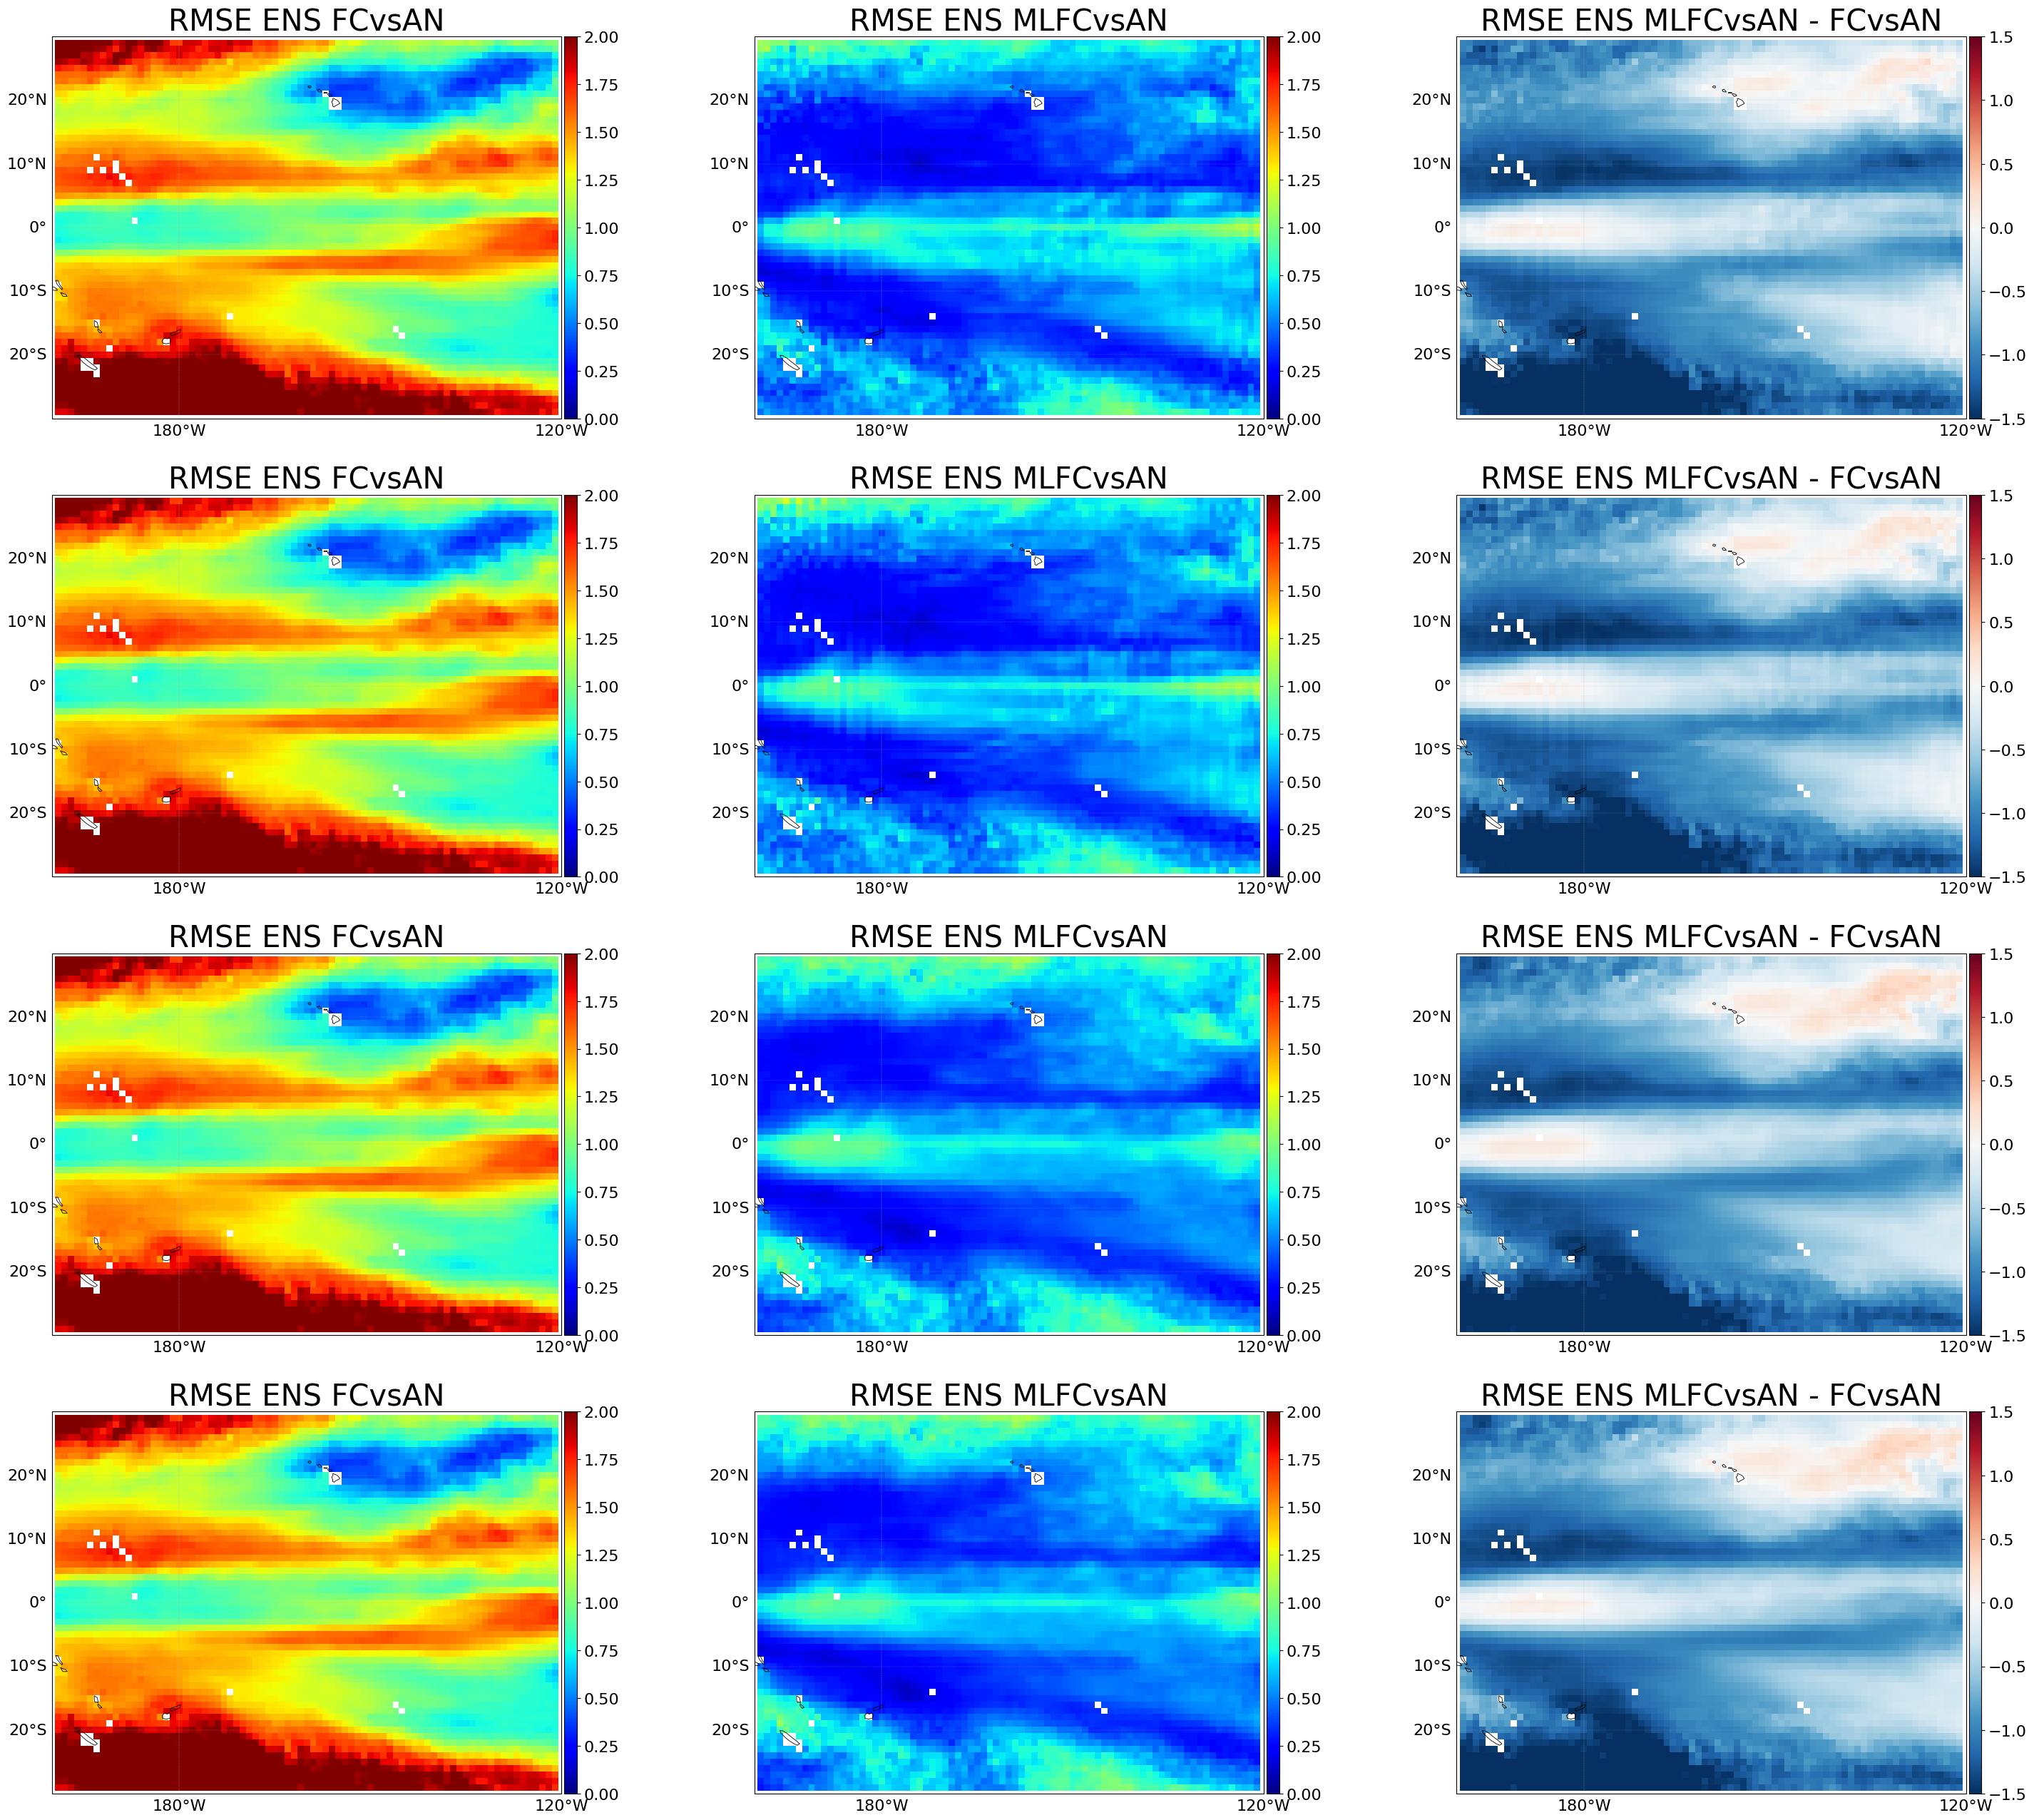

In [110]:
# Metric maps (calculated on time dim) averaged for all R

# User knobs ---
plot_diff = True
metric_type, metric_name, R = "map_ensemble", "rmse", 2 # all
plot_pr = True
# --------------

if use_train_preds:
    condition = type_data=="test" or type_data=="train"
else:
    condition = type_data=="test"

maps = {
    'fc': metrics[train_periods[0]][metric_type].sel(metric=metric_name, model='fc'),
    'pr': metrics[train_periods[0]][metric_type].sel(metric=metric_name, model='pr') if plot_pr else None,
}

if isinstance(R, int) and metric_type == "map_deterministic":
    data_ds_fc = maps['fc'].compute().isel(realization=R).sel(leadtime=[leadtime_plot])
    data_ds_pr = maps['pr'].compute().isel(realization=R).sel(leadtime=[leadtime_plot]) if condition and plot_pr else None
else:
    print("R=all")
    R = "all"
    if metric_type == "map_deterministic":
        data_ds_fc = maps['fc'].compute().mean(dim="realization").sel(leadtime=[leadtime_plot])
        data_ds_pr = maps['pr'].compute().mean(dim="realization").sel(leadtime=[leadtime_plot]) if condition and plot_pr else None
    else:
        data_ds_fc = maps['fc'].compute().sel(leadtime=[leadtime_plot])
        data_ds_pr = maps['pr'].compute().sel(leadtime=[leadtime_plot]) if condition and plot_pr else None
data_ds_an = None

data_type = metric_name if metric_name else "field"

plt_titles_suf = " ENS" if metric_type == "map_ensemble" else ""

da_an, da_fc, da_pr = None, None, None
datasets = []
for var in var_plot_list:
    if condition:
        if data_ds_an is None:
            if data_ds_pr:
                plt_titles = [f"{metric_name.upper() + plt_titles_suf} FCvsAN", f"{metric_name.upper() + plt_titles_suf} MLFCvsAN"]
                suffixes = [f"FCvsAN [R={R}]", f"MLFCvsAN [R={R}]"]
            else:
                plt_titles = [f"{metric_name.upper() + plt_titles_suf} FCvsAN"]
                suffixes = [f"FCvsAN [R={R}]"]
        else:
            plt_titles = [f"{metric_name.upper() + plt_titles_suf} AN", f"{metric_name.upper() + plt_titles_suf} FC", f"{metric_name.upper() + plt_titles_suf} MLFC"]
            suffixes = [f"AN [R={R}]", f"FC [R={R}]", f"MLFC [R={R}]"]
    else:
        plt_titles = [f"AN{metric_name.upper() + plt_titles_suf} ", f"FC{metric_name.upper() + plt_titles_suf} "]
        suffixes = [f"AN [R={R}]", f"FC [R={R}]"]
    # print(f"condition is {condition}")
    das_to_concat = []
    if condition:
        if data_ds_an is None:
            if data_ds_pr:
                da_fc, da_pr = data_ds_fc[var].sel(leadtime=leadtime_plot), data_ds_pr[var].sel(leadtime=leadtime_plot)
                das_to_concat = [da_fc, da_pr]
                if plot_diff:
                    plt_titles.append(f"{metric_name.upper() + plt_titles_suf} MLFCvsAN - FCvsAN")
                    suffixes.append(f"MLFCvsAN - FCvsAN [R={R}]")
                    das_to_concat.append((da_pr - da_fc).assign_coords(model='pr-fc'))
            else:
                da_fc = data_ds_fc[var].sel(leadtime=leadtime_plot)
                das_to_concat = [da_fc]
        else:
            if data_ds_pr:
                da_an, da_fc, da_pr = data_ds_an[var].sel(leadtime=leadtime_plot), data_ds_fc[var].sel(leadtime=leadtime_plot), data_ds_pr[var].sel(leadtime=leadtime_plot)
                das_to_concat = [da_an, da_fc, da_pr]
            else:
                da_an, da_fc = data_ds_an[var].sel(leadtime=leadtime_plot), data_ds_fc[var].sel(leadtime=leadtime_plot)
                das_to_concat = [da_an, da_fc]
    else:
        da_an, da_fc = data_ds_an[var].sel(leadtime=leadtime_plot), data_ds_fc[var].sel(leadtime=leadtime_plot)
        das_to_concat = [da_an, da_fc]

    ds_concat = xr.concat(das_to_concat, dim=data_type)
    ds_concat = ds_concat.assign_coords(**{data_type: suffixes})
    datasets.append(ds_concat)

n_per_row = 2 if da_pr is not None else 1
# Cmaps
inner_cmap_d = {v: n_per_row*list([sel_vars_d[v]["plot"]["cmap"][metric_name]]) for v in sel_vars_d.keys()}
if data_ds_pr and plot_diff:
    for v,c in inner_cmap_d.items():
        inner_cmap_d[v] = c + ["RdBu_r"]
cmap_list = [inner_cmap_d[v] for v,_,_ in product(sel_vars_d.keys(), var_suffix_d.keys(), exp_suffix_root)]

# Limits
inner_limits_d = {v: n_per_row*list([sel_vars_d[v]["plot"]["limits"][metric_name]]) for v in sel_vars_d.keys()}
if data_ds_pr and plot_diff:
    for v,c in inner_limits_d.items():
        if f"diff_{metric_name}" in sel_vars_d[v]["plot"]["limits"].keys():
            inner_limits_d[v] = c + [sel_vars_d[v]["plot"]["limits"][f"diff_{metric_name}"]]
        else:
            inner_limits_d[v] = c + [None]
if len(sel_vars_d.keys())==1:
    var_limits_plot = {"cols": next(iter(inner_limits_d.values()))}
else:
    var_limits_plot = [inner_limits_d[v] for v,_,_ in product(sel_vars_d.keys(), var_suffix_d.keys(), exp_suffix_root)]

print(f"Plot limits: {var_limits_plot}")
print(f"Plot cmaps: {cmap_list}")
# print(len(datasets))
# data_ds = runs['20191011-20241231']['fc'].compute().mean(dim="valid_time").sel(leadtime=[72])
# data_da = data_ds["t2m_mse"]

# data_da
var_seq_suf = [v for v in data_ds_fc.data_vars if v != "_has_var"]
print("Num datasets to plot:", len(datasets), var_seq_suf, suffixes)
# print(data_ds["longitude"].values)
panels = create_panel_from_data(
    datasets,
    col_index=data_type,
    row_index="variable",
    extra_dim_sequence=var_seq_suf,
    # [data_da_an, data_da_fc], col_index="leadtime", row_index="variable",
    # extra_dim_sequence=['AN', 'FC'],
    cmap=cmap_list,
    plt_projection=ccrs.PlateCarree(central_longitude=center_lon),
    data_projection=ccrs.PlateCarree(central_longitude=0), # grid projection, change name in library
    # plt_coastlines=False,
    plt_global_extent=False,
    plt_regional_extent=plt_regional_extent, # wrt new central lon
    limits=var_limits_plot,
    figsize_per_cell=(12,8),
    cbar_mode="subplot",
    gridlabel_mode="all",
    plt_col_titles=plt_titles,
    plt_fontsize=16,
    plt_title_fontsize=30,
    plt_ax_title_pre=f"{type_data} data, leadtime={leadtime_plot}, ",
)
panels["fig"]

In [111]:
import numpy as np
import pandas as pd
from IPython.display import display

# ============================================================
# Configuration
# ============================================================
metrics_list_df = ["rmse", "bias", "mae", "r2", "clim_acc", "spatial_acc", "crps"]

# Example ordering setup:
ordering_metric = "rmse"         # metric used to rank variables
ordering_source = "metric"       # one of: all, avg_real, metric, ens_metric
ordering_model = "pr"            # usually "pr"
ascending_map = {
    "rmse": True,
    "bias": True,   # you may prefer abs(bias), see note below
    "r2": False,
}

# ============================================================
# Helpers
# ============================================================
def _to_float(x):
    try:
        return float(x)
    except TypeError:
        return float(np.asarray(x).item())

def _safe_mean(da):
    return _to_float(da.earthml.geo_mean(da.dims))

def _flatten_valid(pred, obs):
    p = np.asarray(pred).ravel()
    o = np.asarray(obs).ravel()
    mask = np.isfinite(p) & np.isfinite(o)
    return p[mask], o[mask]

def _metric_from_arrays(pred, obs, metric):
    p, o = _flatten_valid(pred, obs)

    if p.size == 0:
        return np.nan

    if metric == "bias":
        return float(np.mean(p - o))

    if metric == "rmse":
        return float(np.sqrt(np.mean((p - o) ** 2)))

    if metric == "r2":
        ss_res = np.sum((o - p) ** 2)
        ss_tot = np.sum((o - np.mean(o)) ** 2)
        if ss_tot == 0:
            return np.nan
        return float(1 - ss_res / ss_tot)

    raise ValueError(f"Unsupported metric: {metric}")

def _mean_over_realization(da):
    return da.mean("realization") if "realization" in da.dims else da

def _metric_from_store(metrics_store, tp, var, model, metric, leadtime_plot, ensemble=False):
    try:
        key = "scalar_ensemble" if ensemble else "scalar_deterministic"
        da = metrics_store[tp][key][var].sel(model=model, metric=metric, leadtime=[leadtime_plot])
        return _to_float(da.mean())
    except Exception:
        try:
            key = "scalar_probabilistic"
            da = metrics_store[tp][key][var].sel(model=model, metric=metric, leadtime=[leadtime_plot])
            return _to_float(da.mean())
        except:
            return np.nan

def summarize_model_vs_an(model_name, pred, an, metrics_store, tp, var, leadtime_plot, metrics_list_df):
    """
    Returns a flat dict:
      mean, err_of_mean, rmse_all, rmse_metric, ...
    """
    out = {}

    out["mean"] = _safe_mean(pred)
    out["err_of_mean"] = _safe_mean(pred) - _safe_mean(an)

    pred_avg_real = _mean_over_realization(pred)
    an_avg_real = _mean_over_realization(an)

    for metric in metrics_list_df:
        # out[f"{metric}_all"] = _metric_from_arrays(pred, an, metric)
        # out[f"{metric}_avg_real"] = _metric_from_arrays(pred_avg_real, an_avg_real, metric)
        out[f"{metric}_metric"] = _metric_from_store(
            metrics_store, tp, var, model_name, metric, leadtime_plot, ensemble=False
        )
        out[f"{metric}_ens_metric"] = _metric_from_store(
            metrics_store, tp, var, model_name, metric, leadtime_plot, ensemble=True
        )

    return out

def _build_metric_rows(metrics_list_df):
    rows = ["mean", "err_of_mean"]
    for metric in metrics_list_df:
        rows.extend([
            # f"{metric}_all",
            # f"{metric}_avg_real",
            f"{metric}_metric",
            f"{metric}_ens_metric",
        ])
    return rows

def _build_pretty_index(metrics_list_df):
    pretty = {
        "mean": "mean",
        "err_of_mean": "error of mean",
    }
    for metric in metrics_list_df:
        # pretty[f"{metric}_all"] = f"{metric} all"
        # pretty[f"{metric}_avg_real"] = f"{metric} avg_real"
        pretty[f"{metric}_metric"] = f"{metric} metric"
        pretty[f"{metric}_ens_metric"] = f"{metric} ens_metric"
    return pretty

def _sort_variables_by_metric(
    var_summaries,
    ordering_metric="rmse",
    ordering_source="metric",
    ascending_map=None,
    use_absolute_for_bias=True,
):
    """
    Sort variables according to one chosen metric key like rmse_metric or r2_all.
    var_summaries: dict[var] -> summary dict
    """
    if ascending_map is None:
        ascending_map = {"rmse": True, "bias": True, "r2": False}

    sort_key = f"{ordering_metric}_{ordering_source}"
    ascending = ascending_map.get(ordering_metric, True)

    items = []
    for var, summary in var_summaries.items():
        value = summary.get(sort_key, np.nan)

        if ordering_metric == "bias" and use_absolute_for_bias and pd.notna(value):
            value = abs(value)

        items.append((var, value))

    # NaNs go last
    items_sorted = sorted(
        items,
        key=lambda x: (pd.isna(x[1]), x[1] if ascending else -x[1] if pd.notna(x[1]) else np.inf)
    )

    return [var for var, _ in items_sorted], sort_key

# ============================================================
# Main builder
# ============================================================
def build_fc_pr_comparison_df(
    runs,
    metrics,
    var_plot_list,
    train_periods,
    leadtime_plot,
    type_data,
    metrics_list_df,
    fc_reference_var=None,
    ordering_metric="rmse",
    ordering_source="metric",
    ordering_model="pr",
    ascending_map=None,
    use_absolute_for_bias=True,
):
    """
    Output dataframe:
      rows   = metric names
      col 1  = fc-an (taken from one selected variable)
      others = pr-an metrics for each variable, ordered by chosen performance metric
    """
    if type_data != "test":
        raise ValueError("This layout needs type_data='test' because it compares fc-an and pr-an.")

    tp = train_periods[0]
    metric_rows = _build_metric_rows(metrics_list_df)
    pretty_index = _build_pretty_index(metrics_list_df)

    # -------------------------
    # Build fc reference column
    # -------------------------
    fc_var = fc_reference_var or var_plot_list[0]
    an_fc = runs[tp]["an"].sel(leadtime=[leadtime_plot])[fc_var]
    fc = runs[tp]["fc"].sel(leadtime=[leadtime_plot])[fc_var]

    fc_summary = summarize_model_vs_an(
        model_name="fc",
        pred=fc,
        an=an_fc,
        metrics_store=metrics,
        tp=tp,
        var=fc_var,
        leadtime_plot=leadtime_plot,
        metrics_list_df=metrics_list_df,
    )

    # -------------------------
    # Build pr summaries
    # -------------------------
    model_summaries = {}

    for var in var_plot_list:
        an = runs[tp]["an"].sel(leadtime=[leadtime_plot])[var]

        if ordering_model == "pr":
            pred = runs[tp]["pr"].sel(leadtime=[leadtime_plot])[var]
        elif ordering_model == "fc":
            pred = runs[tp]["fc"].sel(leadtime=[leadtime_plot])[var]
        else:
            raise ValueError("ordering_model must be 'pr' or 'fc'")

        model_summaries[var] = summarize_model_vs_an(
            model_name=ordering_model,
            pred=pred,
            an=an,
            metrics_store=metrics,
            tp=tp,
            var=var,
            leadtime_plot=leadtime_plot,
            metrics_list_df=metrics_list_df,
        )

    ordered_vars, used_sort_key = _sort_variables_by_metric(
        model_summaries,
        ordering_metric=ordering_metric,
        ordering_source=ordering_source,
        ascending_map=ascending_map,
        use_absolute_for_bias=use_absolute_for_bias,
    )

    # If we're displaying pr columns, but ranking was based on fc,
    # rebuild displayed summaries for pr
    display_summaries = {}
    for var in ordered_vars:
        an = runs[tp]["an"].sel(leadtime=[leadtime_plot])[var]
        pr = runs[tp]["pr"].sel(leadtime=[leadtime_plot])[var]

        display_summaries[var] = summarize_model_vs_an(
            model_name="pr",
            pred=pr,
            an=an,
            metrics_store=metrics,
            tp=tp,
            var=var,
            leadtime_plot=leadtime_plot,
            metrics_list_df=metrics_list_df,
        )

    # -------------------------
    # Final dataframe
    # -------------------------
    data = {
        "fc-an": [fc_summary.get(k, np.nan) for k in metric_rows]
    }

    for var in ordered_vars:
        data[var] = [display_summaries[var].get(k, np.nan) for k in metric_rows]

    df_out = pd.DataFrame(data, index=[pretty_index[k] for k in metric_rows])
    df_out.index.name = "metric"

    return df_out, {
        "fc_reference_var": fc_var,
        "ordered_vars": ordered_vars,
        "ordering_model": ordering_model,
        "ordering_metric": ordering_metric,
        "ordering_source": ordering_source,
        "used_sort_key": used_sort_key,
    }

# ============================================================
# Run
# ============================================================
df_compare, meta = build_fc_pr_comparison_df(
    runs=runs,
    metrics=metrics,
    var_plot_list=var_plot_list,
    train_periods=train_periods,
    leadtime_plot=leadtime_plot,
    type_data=type_data,
    metrics_list_df=metrics_list_df,
    fc_reference_var=None,          # or "t2m"
    ordering_metric="rmse",         # choose: rmse / bias / r2
    ordering_source="metric",       # choose: all / avg_real / metric / ens_metric
    ordering_model="pr",            # usually order variables by PR performance
    ascending_map=ascending_map,
    use_absolute_for_bias=True,
)

styled = (
    df_compare.style
      .format("{:,.6g}")
      .set_caption(
          f"fc-an vs pr-an comparison — train_period={train_periods[0]}, "
          f"leadtime={leadtime_plot}, "
          f"fc-an from '{meta['fc_reference_var']}', "
          f"variables ordered by {meta['ordering_model']}:{meta['used_sort_key']}"
      )
      .set_table_styles([
          {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "600"), ("font-size", "14px")]},
          {"selector": "th", "props": [("text-align", "left"), ("background", "#f5f5f5")]},
          {"selector": "td", "props": [("padding", "4px 8px")]},
      ])
)

display(styled)

2026-03-27 14:28:34,676 - distributed.worker.memory - WARNING - Worker is at 81% memory usage. Pausing worker.  Process memory: 4.33 GiB -- Worker memory limit: 5.33 GiB
2026-03-27 14:28:35,031 - distributed.nanny - WARNING - Restarting worker


,fc-an,sst_geomseloss,sst_mseloss,sst_maskedmseloss,sst_geomaskedmseloss
metric,,,,,
mean,300.428,299.618,299.639,299.602,299.591
error of mean,0.876471,0.0665485,0.0877,0.0503394,0.0394438
rmse metric,1.46109,0.568595,0.576401,0.611487,0.615935
rmse ens_metric,1.38198,0.532866,0.543742,0.566514,0.568918
bias metric,0.876471,0.0665485,0.0877,0.0503394,0.0394438
bias ens_metric,0.876471,0.0665486,0.0877001,0.0503395,0.039444
mae metric,1.19577,0.441129,0.446548,0.472203,0.475056
mae ens_metric,1.13203,0.413488,0.421862,0.438881,0.440348
r2 metric,0.597286,0.938997,0.937325,0.929393,0.928367


In [91]:
# Mask
# data_mask_kind, raw_data_kind = 'pr', 'prediction'

# experiment = joblib.load("/Users/jacopodallaglio/ML/experiments_earthML_ocean/exp_ocean_sst-sosstsst_6months_CentralPacific_19930701-20201231_20210101-20221231_atmo.earthkit.cmcc.hindcast.monthly_ocean.earthkit.oras5.reanalysis.monthly_heterobiascorrectionloss_spatial_usefirstinput/experiment.cfg")
# data_raw = experiment[f"test_data"][raw_data_kind].reload()
# mask_data_raw = ~np.isfinite(data_raw)
# mask_data = ~np.isfinite(runs[train_periods[0]][data_mask_kind][var_plot_list[0]])
# mask = ~np.isfinite(runs[train_periods[0]]['mask'][var_plot_list[0]])

# m_raw = mask_data_raw.compute().isel(realization=0, time=0)
# m_data = mask_data.compute().isel(realization=0, time=0).sel(leadtime=leadtime_plot)
# m = mask.compute().isel(realization=0, time=0).sel(leadtime=leadtime_plot)
# print(f"mask from {data_mask_kind}", m_data.dims, m_data.shape, m_data.dtype)
# print("mask stored", m.dims, m.shape, m.dtype, float(m.max()), float(m.min()))
# # mask

# mask_plot_opts = dict(cmap="gray",x='longitude',y='latitude')
# m_data.hvplot(**mask_plot_opts) + m.hvplot(**mask_plot_opts) + m.hvplot(**mask_plot_opts)

[160. 161. 162. 163. 164. 165. 166. 167. 168. 169. 170. 171. 172. 173.
 174. 175. 176. 177. 178. 179. 180. 181. 182. 183. 184. 185. 186. 187.
 188. 189. 190. 191. 192. 193. 194. 195. 196. 197. 198. 199. 200. 201.
 202. 203. 204. 205. 206. 207. 208. 209. 210. 211. 212. 213. 214. 215.
 216. 217. 218. 219. 220. 221. 222. 223. 224. 225. 226. 227. 228. 229.
 230. 231. 232. 233. 234. 235. 236. 237. 238. 239. 240.]
AN: req_lon=(179, -179), req_lat=(9, 11) | sel_lat=(9.0, 11.0), sel_lon=(160.0, 179.0) | size(px)=3x20 (ny x nx)
FC: req_lon=(179, -179), req_lat=(9, 11) | sel_lat=(9.0, 11.0), sel_lon=(160.0, 179.0) | size(px)=3x20 (ny x nx)
PR: req_lon=(179, -179), req_lat=(9, 11) | sel_lat=(9.0, 11.0), sel_lon=(160.0, 179.0) | size(px)=3x20 (ny x nx)
4 ['sst_mseloss', 'sst_geomseloss', 'sst_maskedmseloss', 'sst_geomaskedmseloss']


cmaps [['jet' 'jet' 'jet']
 ['jet' 'jet' 'jet']
 ['jet' 'jet' 'jet']
 ['jet' 'jet' 'jet']]

limits [[<matplotlib.colors.Normalize object at 0x14fed4d70>
  <matplotlib.colors.Normalize object at 0x14fed4d70>
  <matplotlib.colors.Normalize object at 0x14fed4d70>]
 [<matplotlib.colors.Normalize object at 0x14fed4d70>
  <matplotlib.colors.Normalize object at 0x14fed4d70>
  <matplotlib.colors.Normalize object at 0x14fed4d70>]
 [<matplotlib.colors.Normalize object at 0x14fed4d70>
  <matplotlib.colors.Normalize object at 0x14fed4d70>
  <matplotlib.colors.Normalize object at 0x14fed4d70>]
 [<matplotlib.colors.Normalize object at 0x14fed4d70>
  <matplotlib.colors.Normalize object at 0x14fed4d70>
  <matplotlib.colors.Normalize object at 0x14fed4d70>]]

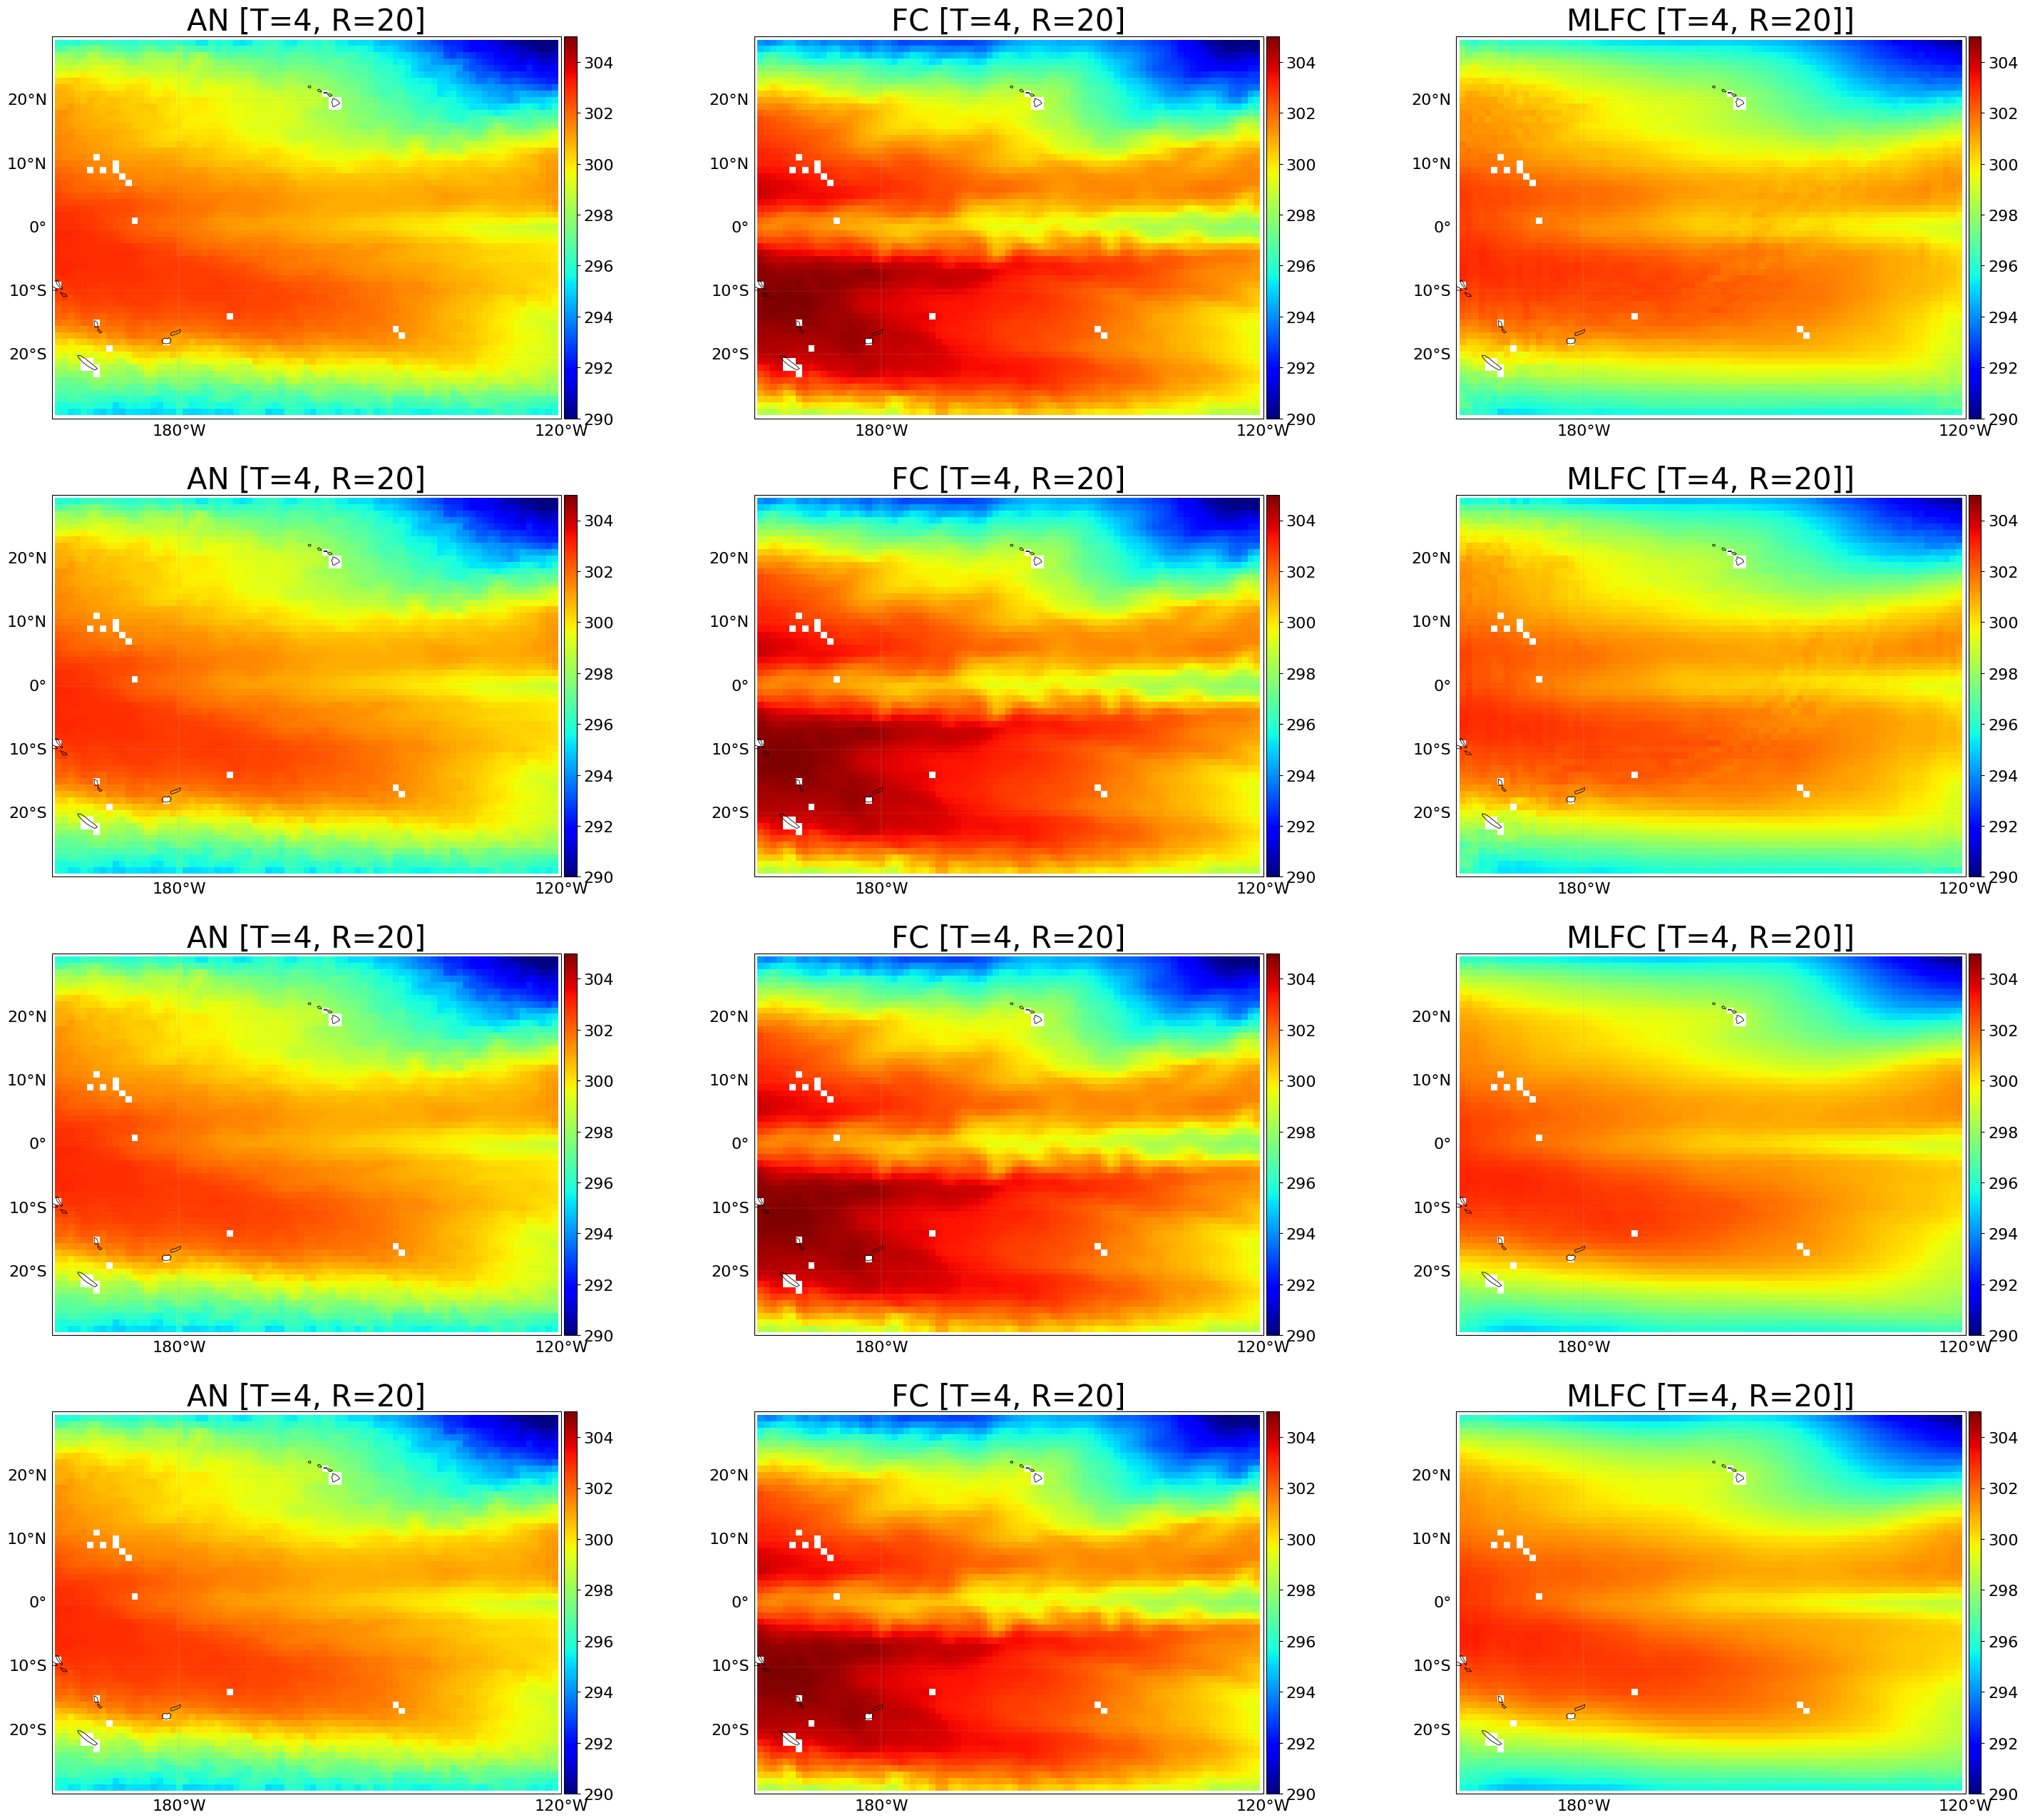

In [112]:
# Select region
# Pacific
if region == "CentralPacific":
    req_lon = (179, -179) # (0, 360)
    req_lat = (9, 11) # (10, -10)
# North Atlantic
elif region == "NorthAtlantic":
    req_lon = (-80, 20) # (0, 360)
    req_lat = (60, 0) # (10, -10)
else:
    req_lon = (0, 360)
    req_lon = (90, -90)

# Limits
full_field_limits = sel_vars_d[sel_vars[0]]['plot']['limits']['field'] # only first var
full_field_cmap = sel_vars_d[sel_vars[0]]["plot"]["cmap"]['field']

# Select time and realization for miniplot
T, R = 4, 20
mean_dim = None # "realization", "time", None, ("realization", "time")

def _slice_for(coord, a, b):
    """
    Build a slice(a,b) that matches the coordinate ordering.
    Works for ascending or descending coords.
    """
    coord0 = float(coord.values[0])
    coord1 = float(coord.values[-1])
    ascending = coord1 > coord0
    lo, hi = (a, b) if a <= b else (b, a)
    return slice(lo, hi) if ascending else slice(hi, lo)

def select_region(da, req_lon, req_lat, lat_name="latitude", lon_name="longitude"):
    lat_sl = _slice_for(da[lat_name], req_lat[0], req_lat[1])
    lon_sl = _slice_for(da[lon_name], req_lon[0], req_lon[1])
    return da.sel({lat_name: lat_sl, lon_name: lon_sl})

def bounds_and_shape(da, lat_name="latitude", lon_name="longitude"):
    lat0 = float(da[lat_name].min())
    lat1 = float(da[lat_name].max())
    lon0 = float(da[lon_name].min())
    lon1 = float(da[lon_name].max())
    ny = int(da.sizes[lat_name])
    nx = int(da.sizes[lon_name])
    return (lat0, lat1), (lon0, lon1), (ny, nx)

def print_region_info(name, da, req_lon, req_lat):
    lat_b, lon_b, (ny, nx) = bounds_and_shape(da)
    print(
        f"{name}: req_lon={req_lon}, req_lat={req_lat} | "
        f"sel_lat={lat_b}, sel_lon={lon_b} | size(px)={ny}x{nx} (ny x nx)"
    )

an_full = runs[train_periods[0]]["an"]
fc_full = runs[train_periods[0]]["fc"]
pr_full = runs[train_periods[0]]["pr"]

print(an_full[lon_dim_an].values)

an_sel = select_region(an_full, req_lon, req_lat)
fc_sel = select_region(fc_full, req_lon, req_lat)
pr_sel = select_region(pr_full, req_lon, req_lat)

sel_lat = (float(an_sel[lat_dim_an].min()), float(an_sel[lat_dim_an].max()))
sel_lon = (float(an_sel[lon_dim_an].min()), float(an_sel[lon_dim_an].max()))

if mean_dim is not None:
    print(f"Plot minimaps with mean {mean_dim}")
    if "realization" in mean_dim:
        R = 0
    if "time" in mean_dim:
        T = 0
    an_full = an_full.mean(dim=mean_dim, keepdims=True)
    fc_full = fc_full.mean(dim=mean_dim, keepdims=True)
    pr_full = pr_full.mean(dim=mean_dim, keepdims=True)

an_full_minimap = an_full.isel(realization=R).sel(leadtime=[leadtime_plot]).isel(time=T)
fc_full_minimap = fc_full.isel(realization=R).sel(leadtime=[leadtime_plot]).isel(time=T)
pr_full_minimap = pr_full.isel(realization=R).sel(leadtime=[leadtime_plot]).isel(time=T)

print_region_info("AN", an_sel, req_lon, req_lat)
print_region_info("FC", fc_sel, req_lon, req_lat)
print_region_info("PR", pr_sel, req_lon, req_lat)

# Plot minimaps

if type_data=="test":
    suffixes = [
        f"AN ["
            f"T={T if mean_dim is None or "time" not in mean_dim else "mean"}, "
            f"R={R if mean_dim is None or "realization" not in mean_dim else "no"}"
        f"]",
        f"FC ["
            f"T={T if mean_dim is None or "time" not in mean_dim else "mean"}, "
            f"R={R if mean_dim is None or "realization" not in mean_dim else "mean"}"
        f"]",
        f"MLFC ["
        f"T={T if mean_dim is None or "time" not in mean_dim else "mean"}, "
        f"R={R if mean_dim is None or "realization" not in mean_dim else "mean"}]"
        f"]",
    ]
else:
    suffixes = [
        f"AN ["
            f"T={T if mean_dim is None or "time" not in mean_dim else "mean"}, "
            f"R={R if mean_dim is None or "realization" not in mean_dim else "no"}"
        f"]",
        f"FC ["
            f"T={T if mean_dim is None or "time" not in mean_dim else "mean"}, "
            f"R={R if mean_dim is None or "realization" not in mean_dim else "mean"}"
        f"]",
    ]

if isinstance(var_plot_list, str):    
    if type_data=="test":
        datasets = [an_full_minimap, fc_full_minimap, pr_full_minimap]
    else:
        datasets = [an_full_minimap, fc_full_minimap]
else:
    datasets = []
    for var in var_plot_list:
        if type_data=="test":
            da_an, da_fc, da_pr = (an_full_minimap[var], fc_full_minimap[var], pr_full_minimap[var])
            da_concat = [da_an.sel(leadtime=leadtime_plot), da_fc.sel(leadtime=leadtime_plot), da_pr.sel(leadtime=leadtime_plot)]
        else:
            da_an, da_fc = (an_full_minimap[var], fc_full_minimap[var])
            da_concat = [da_an.sel(leadtime=leadtime_plot), da_fc.sel(leadtime=leadtime_plot)]
        ds_concat = xr.concat(da_concat, dim="field")
        ds_concat = ds_concat.assign_coords(**{"field": suffixes})
        datasets.append(ds_concat)

print(len(datasets), var_seq_suf)
panels = create_panel_from_data(
    datasets,
    col_index="leadtime" if isinstance(var_plot_list, str) else "field",
    row_index="variable",
    extra_dim_sequence=suffixes if isinstance(var_plot_list, str) else var_seq_suf,
    # [data_da_an, data_da_fc], col_index="leadtime", row_index="variable",
    # extra_dim_sequence=['AN', 'FC', 'PR'],
    cmap=full_field_cmap,
    plt_projection=ccrs.PlateCarree(central_longitude=center_lon),
    data_projection=ccrs.PlateCarree(central_longitude=0), # grid projection, change name in library
    # plt_coastlines=False,
    plt_global_extent=False,
    plt_regional_extent=plt_regional_extent, # wrt new central lon
    limits=full_field_limits,
    figsize_per_cell=(12,8),
    cbar_mode="subplot",
    gridlabel_mode="all",
    plt_col_titles=suffixes,
    plt_fontsize=16,
    plt_title_fontsize=30,
)

# Selected rectangle
from matplotlib.patches import Rectangle

# for ax in panels['axes'].ravel():
#     rect = Rectangle(
#         (sel_lon[0], sel_lat[0]),
#         sel_lon[1] - sel_lon[0],
#         sel_lat[1] - sel_lat[0],
#         fill=False,
#         linewidth=2,
#         zorder=4,
#         transform=ccrs.PlateCarree(),
#     )
#     ax.add_patch(rect)

panels['fig']

In [39]:
# print(metrics[train_periods[0]]['timeseries_deterministic'])
# print(runs[train_periods[0]]["an"])

timeseries_deterministic: ['rmse' 'crmse' 'mae' 'bias' 'r2' 'nrmse' 'ncrmse' 'nmae' 'nbias' 'corr'
 'clim_acc' 'spatial_acc']
timeseries_ensemble: ['rmse' 'crmse' 'mae' 'bias' 'r2' 'nrmse' 'ncrmse' 'nmae' 'nbias' 'corr'
 'clim_acc' 'spatial_acc']
timeseries_probabilistic: ['crps']
var_to_style_idx: {'sst_empiricalcrpsloss_spatial_rasc': 0}
SST CMCC-ORAS5 


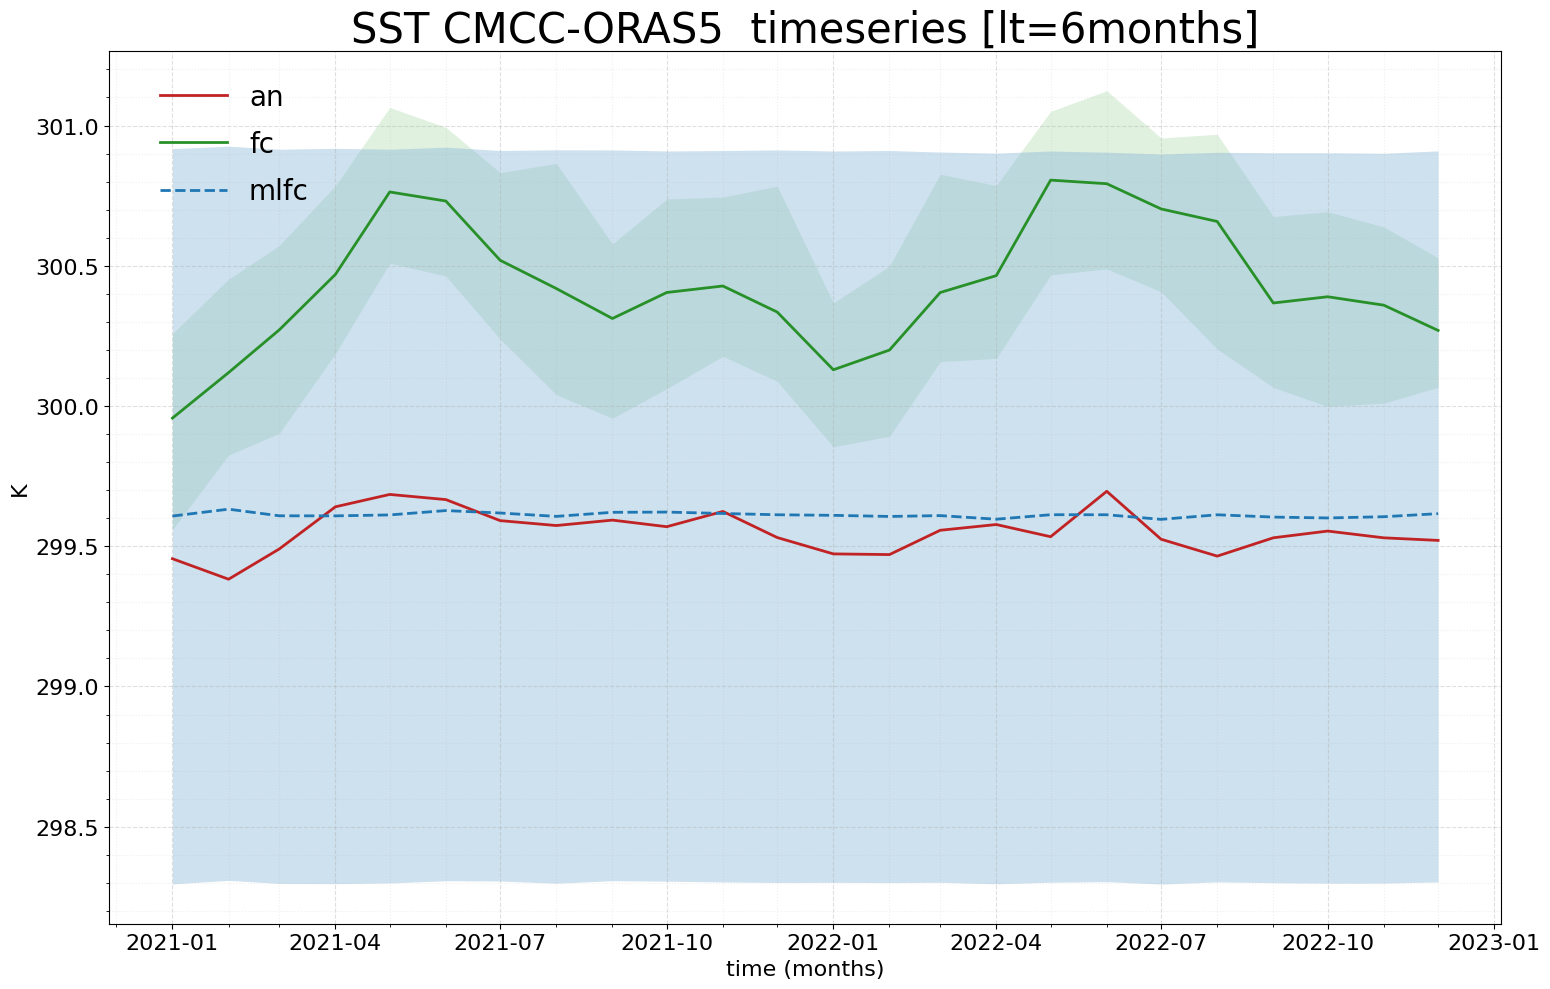

In [93]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import numpy as np

print("timeseries_deterministic:", metrics[train_periods[0]]["timeseries_deterministic"]["metric"].values)
print("timeseries_ensemble:", metrics[train_periods[0]]["timeseries_ensemble"]["metric"].values)
print("timeseries_probabilistic:", metrics[train_periods[0]]["timeseries_probabilistic"]["metric"].values)

# ------------------------------------------------------------
# selectors
# ------------------------------------------------------------
# ts_name: "field" or any metric name in timeseries_deterministic.metric
# ts_type: "plain" or "error"
ts_name = "field"
ts_type = "plain"

# ============================================================
# helpers
# ============================================================
def blend_with_white(color, amount):
    r, g, b = mcolors.to_rgb(color)
    return (
        r + (1 - r) * amount,
        g + (1 - g) * amount,
        b + (1 - b) * amount,
    )

def darken(color, factor):
    r, g, b = mcolors.to_rgb(color)
    return (r * factor, g * factor, b * factor)

def rolling_mean_1d(arr, window):
    if window is None or window <= 1:
        return np.asarray(arr)

    arr = np.asarray(arr, dtype=float)
    out = np.full_like(arr, np.nan, dtype=float)

    valid = np.isfinite(arr).astype(float)
    arr0 = np.where(np.isfinite(arr), arr, 0.0)

    kernel = np.ones(window, dtype=float)
    num = np.convolve(arr0, kernel, mode="same")
    den = np.convolve(valid, kernel, mode="same")

    mask = den > 0
    out[mask] = num[mask] / den[mask]
    return out

def maybe_smooth(arr, use_rolling_mean=False, rolling_mean_window=5):
    if not use_rolling_mean:
        return np.asarray(arr)
    return rolling_mean_1d(arr, rolling_mean_window)

def get_mean_lower_upper(da, leadtime):
    sel = da.sel(leadtime=leadtime)
    if "realization" in sel.dims:
        mean = sel.mean(dim="realization")
        lower = sel.min(dim="realization")
        upper = sel.max(dim="realization")
    else:
        mean = sel
        lower = sel
        upper = sel
    return mean, lower, upper

def get_pr_style(idx, colors, linestyles):
    n_colors = len(colors)
    color = colors[idx % n_colors]
    linestyle = linestyles[(idx // n_colors) % len(linestyles)]
    return color, linestyle

def subset_time_series(da, time_dim, x_time_range=None):
    """
    Restrict a DataArray/Dataset along its time dimension.

    x_time_range can be:
      - None
      - ("YYYY-MM-DD", "YYYY-MM-DD")
      - (start, end) where either side can be None
    """
    if x_time_range is None:
        return da

    start, end = x_time_range

    if start is None and end is None:
        return da
    if start is None:
        return da.sel({time_dim: slice(None, end)})
    if end is None:
        return da.sel({time_dim: slice(start, None)})

    return da.sel({time_dim: slice(start, end)})

def plot_band_and_mean(
    ax,
    x,
    da,
    leadtime,
    line_color,
    fill_color=None,
    linestyle="-",
    linewidth=2.0,
    alpha_fill=0.22,
    zorder_fill=1,
    zorder_line=2,
    use_rolling_mean=False,
    rolling_mean_window=5,
):
    mean, lower, upper = get_mean_lower_upper(da, leadtime)

    mean = maybe_smooth(mean.values, use_rolling_mean, rolling_mean_window)
    lower = maybe_smooth(lower.values, use_rolling_mean, rolling_mean_window)
    upper = maybe_smooth(upper.values, use_rolling_mean, rolling_mean_window)

    if fill_color is not None and alpha_fill > 0:
        ax.fill_between(
            x,
            lower,
            upper,
            color=mcolors.to_rgba(fill_color, alpha=alpha_fill),
            linewidth=0,
            zorder=zorder_fill,
        )

    ax.plot(
        x,
        mean,
        color=line_color,
        linestyle=linestyle,
        linewidth=linewidth,
        zorder=zorder_line,
    )

# ============================================================
# config
# ============================================================
an_color = "tab:red"
fc_color = "tab:green"
err_fc_color = "tab:brown"
base_linestyle = "-"

pr_colors = ["tab:blue", "tab:orange", "black", "tab:purple"]
pr_linestyles = ["--", "-", "-.", ":"]

use_pr_band = True
pr_band_alpha = 0.40

# rolling mean config
use_rolling_mean = False
rolling_mean_window = 5

# x-axis time range config
# Examples:
x_time_range = None
# x_time_range = (datetime(2018, 1, 1), datetime(2020, 12, 31))
# x_time_range = ("2020-01-01", None)
# x_time_range = (None, "2021-12-31")

leadtimes_ts = [leadtime_plot]

pr_labels = list(var_plot_list)

global_xmin, global_xmax = None, None
global_ymin, global_ymax = None, None

var_plot_units = [all_vars_d[v]["units"] for v, loss in product(sel_vars_d.keys(), var_suffix_d.keys())]
var_to_style_idx = {v: i for i, v in enumerate(var_plot_list)}
print("var_to_style_idx:", var_to_style_idx)

# ============================================================
# build time series
# ============================================================
has_pr = True
try:
    _ = runs[train_periods[0]].get("pr", None)
    if _ is None:
        has_pr = False
except Exception:
    has_pr = False

if ts_name == "field":
    an_full = runs[train_periods[0]]["an"]
    fc_full = runs[train_periods[0]]["fc"]

    ts_an = an_full.earthml.geo_mean((lat_dim_an, lon_dim_an))
    ts_fc = fc_full.earthml.geo_mean((lat_dim_an, lon_dim_an))

    ts_pr_by_period = {}

    if has_pr:
        for tp, label in product(train_periods, pr_labels):
            try:
                pr_data = runs[tp].get("pr", None)
                if pr_data is None:
                    continue

                ts_pr_by_period[(tp, label)] = pr_data.earthml.geo_mean((lat_dim_an, lon_dim_an))
            except Exception:
                continue

else:
    m_ts0 = metrics[train_periods[0]]["timeseries_deterministic"].sel(metric=ts_name)

    ts_an = None
    try:
        ts_an = m_ts0.sel(model="an")
    except Exception:
        pass

    ts_fc = m_ts0.sel(model="fc")

    ts_pr_by_period = {}

    for tp, label in product(train_periods, pr_labels):
        try:
            pr_candidate = (
                metrics[tp]["timeseries_deterministic"]
                .sel(metric=ts_name)
                .sel(model="pr")
            )
            if pr_candidate is not None:
                ts_pr_by_period[(tp, label)] = pr_candidate
        except Exception:
            continue

# x dims for fixed series
fixed_series = []
pr_series_by_period = {}

if ts_type == "plain":
    if ts_an is not None:
        fixed_series.append(("an", ts_an, time_dim_an, an_color))
    fixed_series.append(("fc", ts_fc, time_dim_fc, fc_color))

    pr_series_by_period = ts_pr_by_period.copy()

elif ts_type == "error":
    if ts_an is None:
        raise ValueError(f"ts_type='error' requires an 'an' series, but none was found for ts_name={ts_name!r}")

    # fc - an
    ts_fc_err = ts_fc - ts_an
    fixed_series.append(("fc-an", ts_fc_err, time_dim_fc, err_fc_color))

    # pr - an
    for (tp, label), ts_pr in ts_pr_by_period.items():
        if ts_pr is None:
            continue
        try:
            pr_series_by_period[(tp, label)] = ts_pr - ts_an
        except Exception:
            continue

else:
    raise ValueError(f"Unknown ts_type={ts_type!r}. Use 'plain' or 'error'.")

# ============================================================
# figure / axes
# ============================================================
nrows = len(var_plot_list) if len(leadtimes_ts) > 1 else 1
fig, axs = plt.subplots(
    ncols=1,
    nrows=nrows,
    figsize=(20, 10 * nrows),
    squeeze=False,
)
axs = axs.flatten()

n_leadtimes = len(leadtimes_ts)
var_outer_list = var_plot_list if len(leadtimes_ts) > 1 else [None]
var_inner_list = [None] if len(leadtimes_ts) > 1 else var_plot_list

# ============================================================
# main plotting loop
# ============================================================
for j, vo in zip(range(nrows), var_outer_list):
    ax = axs[j]

    for i, lt in enumerate(leadtimes_ts):
        lt_frac = i / (n_leadtimes - 1) if n_leadtimes > 1 else 0.0

        for vi in var_inner_list:
            var = vi if vo is None else vo

            # --------------------------------------------
            # fixed series
            # --------------------------------------------
            for lab, ts, time_dim, base_color in fixed_series:
                ts_plot = subset_time_series(ts, time_dim, x_time_range)

                fill_color = blend_with_white(base_color, amount=0.35 + 0.25 * lt_frac)
                line_color = darken(base_color, factor=0.90 - 0.10 * lt_frac)

                plot_band_and_mean(
                    ax=ax,
                    x=ts_plot[time_dim],
                    da=ts_plot[var],
                    leadtime=lt,
                    line_color=line_color,
                    fill_color=fill_color,
                    linestyle=base_linestyle,
                    linewidth=2.0,
                    alpha_fill=0.22,
                    zorder_fill=1,
                    zorder_line=2,
                    use_rolling_mean=use_rolling_mean,
                    rolling_mean_window=rolling_mean_window,
                )

            # --------------------------------------------
            # PR series
            # --------------------------------------------
            if pr_series_by_period:
                pr_items_for_var = [
                    (tp, label, ts_pr)
                    for (tp, label), ts_pr in pr_series_by_period.items()
                    if label == var and ts_pr is not None
                ]
            else:
                pr_items_for_var = []

            for tp, label, ts_pr in pr_items_for_var:
                ts_pr_plot = subset_time_series(ts_pr, time_dim_pr, x_time_range)

                style_idx = var_to_style_idx[label]

                pr_line_color, pr_linestyle = get_pr_style(
                    style_idx,
                    pr_colors,
                    pr_linestyles,
                )

                pr_fill_color = blend_with_white(pr_line_color, 0.45) if use_pr_band else None

                plot_band_and_mean(
                    ax=ax,
                    x=ts_pr_plot[time_dim_pr],
                    da=ts_pr_plot[var],
                    leadtime=lt,
                    line_color=pr_line_color,
                    fill_color=pr_fill_color,
                    linestyle=pr_linestyle,
                    linewidth=2.0 if n_leadtimes == 1 else 1.8 - 0.2 * lt_frac,
                    alpha_fill=pr_band_alpha if use_pr_band else 0.0,
                    zorder_fill=1,
                    zorder_line=3,
                    use_rolling_mean=use_rolling_mean,
                    rolling_mean_window=rolling_mean_window,
                )

    nice = var_plot_nicename_list[j] if j < len(var_plot_nicename_list) else var
    print(var_plot_nicename_list[j])

    if ts_type == "plain":
        title_label = f"{ts_name.upper()} " if ts_name != 'field' else ''
    else:
        title_label = f"{ts_name.upper()} error " if ts_name != 'field' else 'Error '

    smooth_suffix = f" | rolling mean (window={rolling_mean_window})" if use_rolling_mean else ""
    ax.set_title(f"{nice} {title_label}timeseries [lt={leadtime_plot}{leadtime_unit}]{smooth_suffix}", fontsize=30)
    ax.set_ylabel(var_plot_units[j], fontsize=16)
    ax.set_xlabel(f"time ({leadtime_unit})", fontsize=16)

    # apply explicit config time range if provided
    if x_time_range is not None:
        ax.set_xlim(*x_time_range)
    elif global_xmin is not None and global_xmax is not None:
        ax.set_xlim(global_xmin, global_xmax)

    if global_ymin is not None and global_ymax is not None:
        ax.set_ylim(global_ymin, global_ymax)

    ymin, ymax = ax.get_ylim()
    if ymin <= 0 <= ymax:
        ax.axhline(0.0, color="0.3", lw=1.0, ls=":")

    ax.grid(True, which="major", linestyle="--", alpha=0.4)
    ax.grid(True, which="minor", linestyle=":", alpha=0.2)

    ax.minorticks_on()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))

    ax.tick_params(axis='both', which='major', labelsize=16)

# ============================================================
# legend
# ============================================================
legend_handles = []

if ts_type == "plain":
    if ts_an is not None:
        legend_handles.append(
            Line2D([0], [0], color=darken(an_color, 0.9), lw=2, linestyle="-", label="an")
        )

    legend_handles.append(
        Line2D([0], [0], color=darken(fc_color, 0.9), lw=2, linestyle="-", label="fc")
    )
else:
    legend_handles.append(
        Line2D([0], [0], color=darken(err_fc_color, 0.9), lw=2, linestyle="-", label="fc-an")
    )

seen_labels = set()
if pr_series_by_period:
    for var in var_plot_list:
        pr_items_for_var = [
            (tp, label)
            for (tp, label) in pr_series_by_period.keys()
            if label == var
        ]

        for tp, label in pr_items_for_var:
            legend_label = f"mlfc-an" if ts_type == "error" else f"mlfc"
            # legend_label = f"pr-an ({tp}, {label})" if ts_type == "error" else f"pr ({tp}, {label})"
            if legend_label in seen_labels:
                continue
            seen_labels.add(legend_label)

            style_idx = var_to_style_idx[label]
            pr_line_color, pr_linestyle = get_pr_style(
                style_idx,
                pr_colors,
                pr_linestyles,
            )

            legend_handles.append(
                Line2D(
                    [0], [0],
                    color=pr_line_color,
                    lw=2,
                    linestyle=pr_linestyle,
                    label=legend_label,
                )
            )

if len(leadtimes_ts) > 1:
    leadtime_handles = [
        Line2D(
            [0], [0],
            color="black",
            lw=2,
            linestyle=pr_linestyles[i % len(pr_linestyles)],
            label=f"leadtime={ll}",
        )
        for i, ll in enumerate(leadtimes_ts)
    ]
    legend_handles += leadtime_handles

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.07, 0.85),
    frameon=False,
    ncol=1,
    fontsize=20,
    handlelength=2.4,
    labelspacing=0.7,
)

fig.tight_layout(rect=[0, 0, 0.78, 1.0])
plt.show()

Plot 0/1


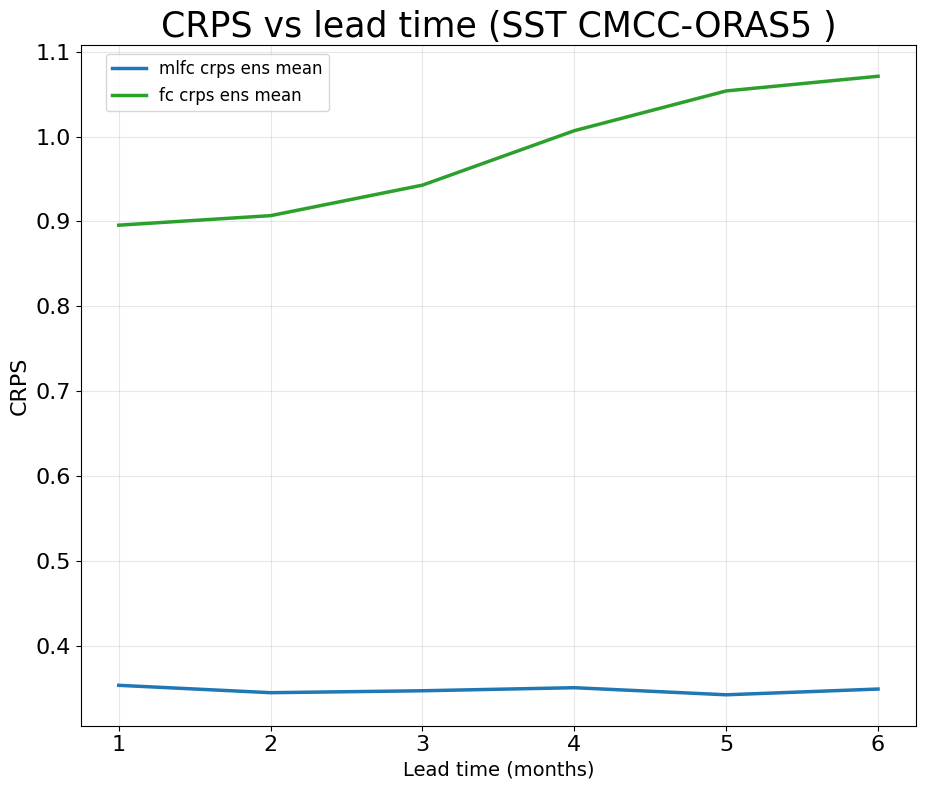

In [17]:
scalar_metric, metric_type = 'crps', 'scalar_probabilistic'
# scalar_metric, metric_type = 'r2', 'scalar_ensemble'

ncols = 1
nrows = len(var_plot_list)

assert nrows > 0, "var_plot_list is empty"

base_w, base_h = 12.0, 8.0
max_w, max_h = 24, 24

fig_width  = min(base_w * ncols, max_w)
fig_height = min(base_h * nrows, max_h)

fig, axs = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    figsize=(fig_width, fig_height),
    squeeze=False
)
axs = axs.ravel()

real_type = 'scalar_probabilistic' if metric_type=='scalar_probabilistic' else 'scalar_deterministic'

for i, var_plot in enumerate(var_plot_list):
    print(f"Plot {i}/{len(axs)}")
    ax = axs[i]

    if type_data == "test":
        metric_ens_pr = metrics[train_periods[0]][metric_type][var_plot].sel(model='pr', metric=scalar_metric)
        metric_R_pr   = metrics[train_periods[0]][real_type][var_plot].sel(model='pr', metric=scalar_metric)

    metric_ens_fc = metrics[train_periods[0]][metric_type][var_plot].sel(model='fc', metric=scalar_metric)
    metric_R_fc   = metrics[train_periods[0]][real_type][var_plot].sel(model='fc', metric=scalar_metric)

    if type_data == "test":
        plot_ensemble_leadtime(
            ens_mean=metric_ens_pr if metric_type=='scalar_probabilistic' else metric_R_pr.mean(dim="realization"),
            members=None if metric_type=='scalar_probabilistic' else metric_R_pr,
            extra=None if metric_type=='scalar_probabilistic' else metric_ens_pr,
            label=f"mlfc {scalar_metric}",
            color="tab:blue",
            ax=ax,
            extra_label=f"mlfc {scalar_metric} ensemble",
            spread="minmax",
        )

    plot_ensemble_leadtime(
        ens_mean=metric_ens_fc if metric_type=='scalar_probabilistic' else metric_R_fc.mean(dim="realization"),
        members=None if metric_type=='scalar_probabilistic' else metric_R_fc,
        extra=None if scalar_metric=='crps' else metric_ens_fc,
        label=f"fc {scalar_metric}",
        color="tab:green",
        ax=ax,
        extra_label=f"fc {scalar_metric} ensemble",
        spread="minmax",
    )

    ax.set_title(f"{scalar_metric.upper()} vs lead time ({var_plot_nicename_list[i]})", fontsize=25)
    ax.set_ylabel(scalar_metric.upper(), fontsize=16)
    ax.set_xlabel("Lead time (months)", fontsize=14)
    if scalar_metric in ("r2", "spatial_acc"): # larger, better
        ax.legend(loc="upper left", bbox_to_anchor=(0.03, 0.3), fontsize=12)
    elif scalar_metric in ("clim_acc",):
        ax.legend(loc="upper left", bbox_to_anchor=(0.03, 0.7), fontsize=12)
    else: # smaller, better
        ax.legend(loc="upper left", bbox_to_anchor=(0.02, 1), fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout(rect=[0, 0, 0.78, 1.0])
plt.show()

In [42]:
print(metrics[train_periods[0]].keys())

metrics_sb = ["rmse", "mae", "bias", "r2", "corr", "clim_acc", "spatial_acc", "nrmse"]
# metrics_sb = ["rmse_ens", "mae_ens", "bias_ens", "r2_ens", "corr_ens", "acc_ens]
df_delta = metrics_to_df(
    metrics,
    variables=None,
    metric_names=metrics_sb,
    kind="scalar",
    metric_type='ensemble',
    diff="delta", # no, delta, ratio
    models=['fc', 'pr'],
)

df_ratio = metrics_to_df(
    metrics,
    variables=None,
    metric_names=metrics_sb,
    kind="scalar",
    metric_type='ensemble',
    diff="ratio", # no, delta, ratio
    models=['fc', 'pr'],
)

df = metrics_to_df(
    metrics,
    variables=None,
    metric_names=metrics_sb,
    kind="scalar",
    metric_type='ensemble',
    diff="no", # no, delta, ratio
    models=['fc', 'pr'],
)

dict_keys(['scalar_deterministic', 'map_deterministic', 'timeseries_deterministic', 'scalar_ensemble', 'map_ensemble', 'timeseries_ensemble', 'scalar_probabilistic', 'map_probabilistic', 'timeseries_probabilistic'])


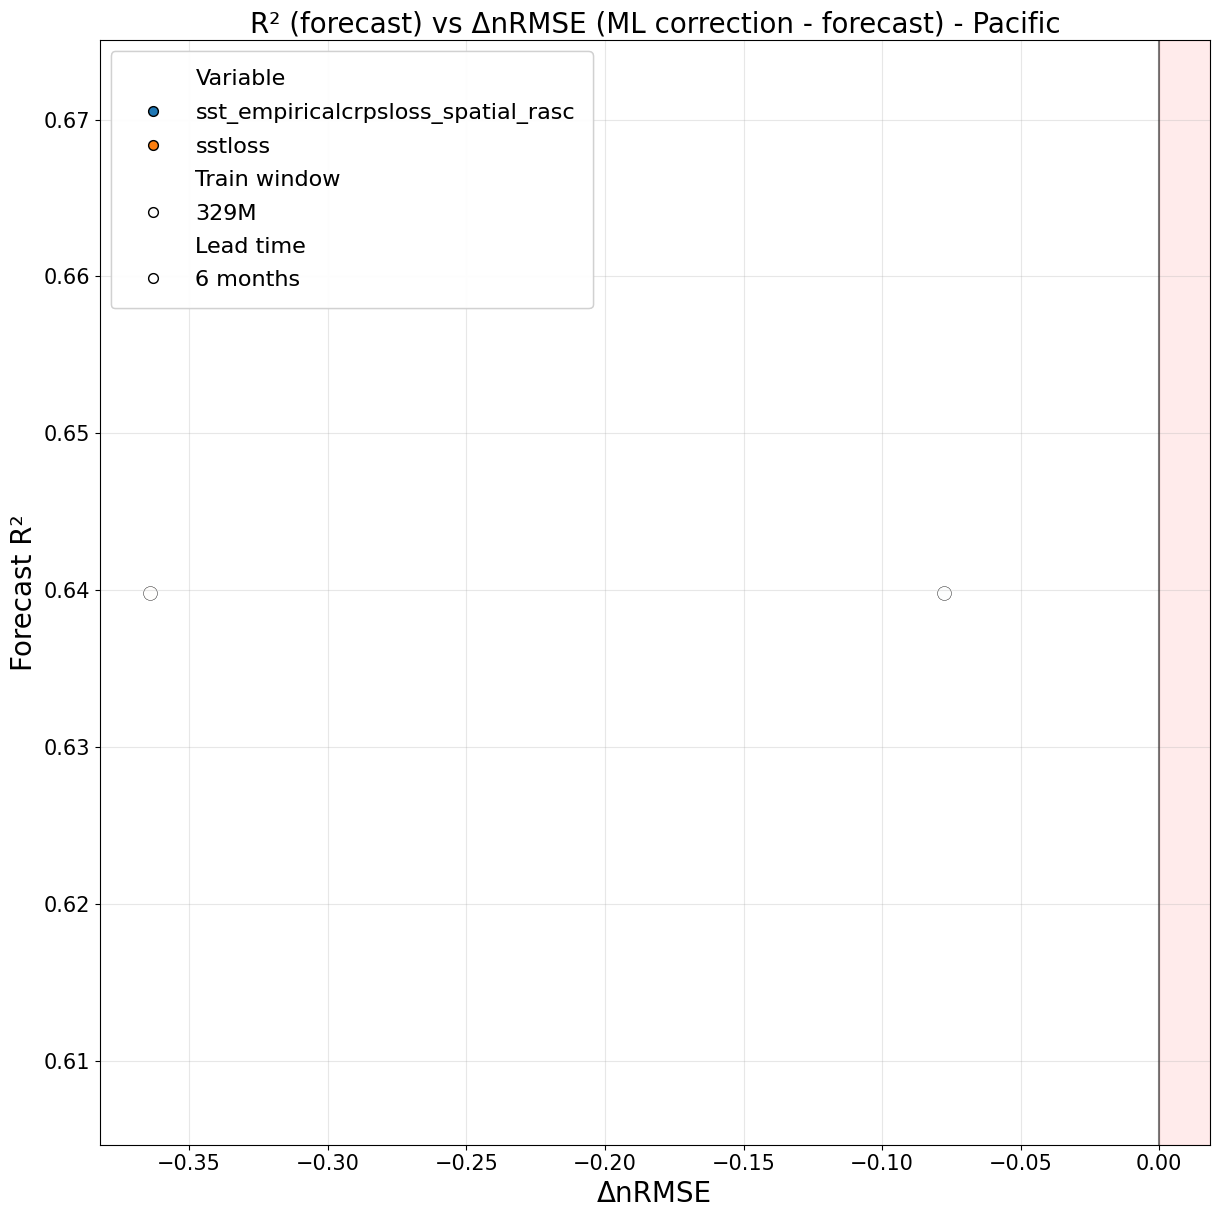

In [43]:
# metric vs diff

delta_metrics_df = df_delta[df_delta['model']=='pr-fc']
ratio_metrics_df = df_ratio[df_ratio['model']=='pr-fc']
fc_metrics_df = df[df['model']=='fc']
pr_metrics_df = df[df['model']=='pr']

sel_metric = {"metric": "r2", "name": "R²"}
# sel_metric = {"metric": "nrmse_global", "name": "nRMSE"}
# sel_metric = {"metric": "corr_global", "name": "Correlation"}
# sel_metric = {"metric": "corr_flat", "name": "Correlation"}

diff_metric = {"metric": "nrmse", "name": "ΔnRMSE"}
# diff_metric = {"metric": "mape", "name": "ΔMAPE"}
# diff_metric = {"metric": "smape", "name": "ΔSMAPE"}
# diff_metric = {"metric": "rmse", "name": "ΔRMSE"} # ratio
# diff_metric = {"metric": "nmae_global", "name": "ΔnMAE"}
# diff_metric = {"metric": "nbias_global", "name": "ΔnBias"}
# diff_metric = {"metric": "abs_nbias_global", "name": "ΔnAbsBias"}

exclude_vars = ("ke", "tcc", "_het")

fig, ax, merged = plot_metric_vs_diff(
    fc_metrics_df,
    delta_metrics_df,
    forecast_metric=sel_metric["metric"],
    # forecast_metric="corr_global",
    diff_metric=diff_metric["metric"],
    xlabel=f"{diff_metric["name"]}",
    ylabel=f"Forecast {sel_metric["name"]}",
    # ylabel="Forecast Corr",
    title=f"{sel_metric["name"]} (forecast) vs {diff_metric["name"]} (ML correction - forecast) - Pacific",
    shade_strength=0.99,
    # fit_lines=True,
    # fit_min_points=4,
    # fit_ci=False,
    legend_fontsize=16,
    # legend_loc="lower right",
    legend_loc="upper left",
    point_size=100,
    leadtime_unit=" months",
    filters={
        # "variable": ["d2m_mse"]
        # "variable": [v for v in vars_mse+vars_het if not any(s in v.lower() for s in exclude_vars)],
        # "total_months": [3, 62],
        # "leadtime": [12, 24, 48, 72],
    },
)
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.title.set_fontsize(20)

# fig.savefig(f"/work/cmcc/jd19424/test-ML/plots_earthML_weather/{sel_metric["metric"]}-delta_{diff_metric["metric"]}.png", bbox_inches="tight", dpi=150)

fig.show()

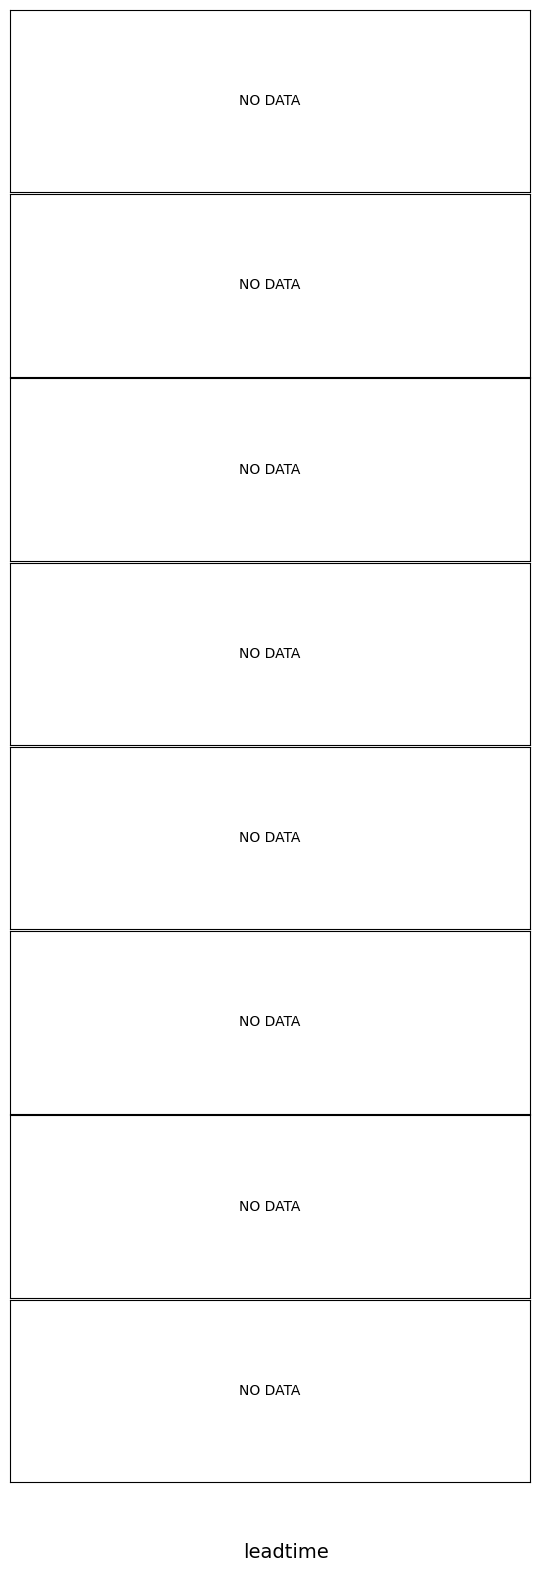

In [44]:
fig = plot_scoreboard(
    df=df,
    outer_y={"index": "metric", "values": metrics_sb},
    # outer_x={"index": "model", "values": ["fc", "pr"]},
    outer_x={"index": "model", "values": ["pr-fc"]},
    inner_y={"index": "variable"},
    inner_x={"index": "leadtime"},
    filters={"train_period": train_periods[0]},
    agg="mean",
    # metric_cmaps={"rmse": "Blues", "mae": "Blues", "bias": "RdBu", "mape": "Blues"},
    metric_cmaps={"rmse": "RdBu_r", "mae": "RdBu_r", "bias": "RdBu_r", "r2": "RdBu", "corr": "RdBu", "spatial_acc": "RdBu", "clim_acc": "RdBu"},
    # metric_vlims={"rmse": (0, 1.8), "mae": (0, 1.3), "bias": (-0.30, 0.30), "mape": (0, 0.35)},
    metric_vlims={"rmse": (-1.2, 1.2), "mae": (-0.85, 0.85), "bias": (-0.35, 0.35), "r2": (-0.6, 0.6), "corr": (-0.18, 0.18), "spatial_acc": (-0.15, 0.15)},
    metric_names=None,
    metric_factor=1,
    figsize=(6, 16),
    cell_size=(0.8, 0.5),   # (width_per_score, height_per_score) in inches
    wspace=0.01,
    hspace=0.01,
    title=None,
    plt_title_fontsize=20,
    plt_outer_fontsize=14,
    plt_inner_fontsize=10,
    cbar_show=True,
    cbar_width=0.08,
    annotate=True,
    annotate_fmt="{:.2f}",
    annotate_color="auto",
    save_path=None,
    panel_select={
        "fc": {"inner_x": 1},
        "pr": {"inner_x": None},
    }
)
fig.subplots_adjust(left=0.04, right=0.98, top=0.98, bottom=0.06)
fig.supylabel("")
fig

In [96]:
leadtime_clim = 6
# lat_slice, lon_slice = slice(30, -30), slice(160, 240)
lat_slice, lon_slice = slice(4, -4), slice(180, 200)

var_anom_plot = var_plot_list[0]

def area_mean_anomaly(ds, clim, var, leadtime, lat_slice, lon_slice):
    da = ds[var].sel(leadtime=leadtime)
    clim = clim[var].sel(leadtime=leadtime)
    anom = (da.groupby("time.month") - clim)
    return anom.sel(latitude=lat_slice, longitude=lon_slice).mean(
        dim=("latitude", "longitude", "realization")
    )

an_anom = area_mean_anomaly(runs[train_periods[0]]["an"], clim_ts[0], var_anom_plot, leadtime_clim, lat_slice, lon_slice)
fc_anom = area_mean_anomaly(runs[train_periods[0]]["fc"], clim_ts[1], var_anom_plot, leadtime_clim, lat_slice, lon_slice)
pr_anom = area_mean_anomaly(runs[train_periods[0]]["pr"], clim_ts[0], var_anom_plot, leadtime_clim, lat_slice, lon_slice)

(an_anom.hvplot.line(x="time", label="AN") *
 fc_anom.hvplot.line(x="time", label="FC") *
 pr_anom.hvplot.line(x="time", label="MLFC")
)

:Overlay
   .Curve.AN   :Curve   [time]   (Sea Surface temperature)
   .Curve.FC   :Curve   [time]   (Sea surface temperature)
   .Curve.MLFC :Curve   [time]   (Sea Surface temperature)

In [93]:
an_clim

<xarray.DataArray 'sst_mseloss' (month: 12, latitude: 61, longitude: 81,
                                 realization: 30)> Size: 14MB
dask.array<getitem, shape=(12, 61, 81, 30), dtype=float64, chunksize=(12, 61, 81, 30), chunktype=numpy.ndarray>
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    leadtime     (month) int64 96B 2 2 2 2 2 2 2 2 2 2 2 2
  * latitude     (latitude) float64 488B 30.0 29.0 28.0 ... -28.0 -29.0 -30.0
  * longitude    (longitude) float64 648B 160.0 161.0 162.0 ... 239.0 240.0
  * realization  (realization) int64 240B 0 1 2 3 4 5 6 ... 23 24 25 26 27 28 29
Attributes:
    standard_name:       Sea Surface temperature
    long_name:           Sea Surface temperature
    units:               K
    online_operation:    ave(x)
    interval_operation:  1200.0
    interval_write:      2678400.0
    offline_operation:   ave(x)
    institution:         ECMWF